In [1]:
import numpy as np
import scipy as sp
import subprocess
from solephem import solephem
import datetime as datetime
from copy import copy, deepcopy
import sunpy.map
import matplotlib.patches as patches
from scipy.signal import gaussian
from scipy.special import voigt_profile
import os
from datetime import date

# ToDo List
- early version possible if I stick to constant cadence on the PHI side
- cadence adaptive weight functions
    - introduce local weight function depending on the variable cadence across the map
    - plateau functions in the HMI range
    - variable WF width over the PHI range

# Notes
- len[2] array had to be renamed to length due to pyhton len() function
- MIN() / MAX() in the C implementation are supposed to return integers but rounding errors are introduced if I treat them as integers in python. Prevailing rounding mode might be different on DRMS server. Python implementation uses float returns on min/max operations instead.
- comparing the python with the C output produces a column with residual signal in column 2509 at the end of inRec 3. This is most likely a rounding issue as the mrc value is xxxx.52 and rounded up in python. This problem is fixed if the mrc is rounded down for inRec 3. This fix introduces residual signal in col 2399 at the same time, as the columns wrongly missing when processed for the other nsynop part. Overall this will produce a slightly different synoptic map than the C code but shouldn't matter in the long run.

# Code

## Defines

In [2]:
# DEFINES
QUAL_CHECK = "0xfffefb00"

C1  =  0.0757644       ##/* days/degree at 27.27527 */
C2  = 92353.9357       ##/* day of 1853:11:09_22h:27m:24s */
PI  = 3.14159265358979323844
SID = 86400.0
RADSINDEG = PI / 180
SHRT_MAX = 32767
SHRT_MIN = -SHRT_MAX -1
DRMS_MISSING_FLOAT = np.nan    
kNOISE_EQ = 10.0 # redefined in CalcSynopCol but unused

## DRMS Interface

In [3]:
def get_drms_parameters(inRecs, input_ds):

    #inRecs = "2014.05.12_12:00:00_TAI, 2014.05.13_00:00:00_TAI, 2014.05.13_12:00:00_TAI, 2014.05.14_00:00:00_TAI" # input argument
    
    #nRecs = len(inRecs.split(','))
    #show_info = 'show_info %s["%s"] key="CALVER64,T_REC,QUALITY,FDRADIAL,CARSTRCH,DIFROT_A,DIFROT_B,DIFROT_C,CRVAL1,CRLN_OBS,CAR_ROT,MAPLGMAX,MAPLGMIN,MAPMMAX,I_DREC" -iPA'
    show_info = 'show_info %s["%s"] key="CALVER64,T_REC,QUALITY,FDRADIAL,CARSTRCH,DIFROT_A,DIFROT_B,DIFROT_C,CRVAL1,CRLN_OBS,CAR_ROT,MAPLGMAX,MAPLGMIN,MAPMMAX,I_DREC" -iPA' 
    
    #-P for path and -A for segment
    
    si_out = subprocess.check_output(show_info %(input_ds, inRecs) , shell=True)[:-1].decode("utf-8")
    raw = si_out.split('\n')
    
    formatted = [] 
    drms_param = []
    
    nRecs = 0
    keys = raw[0].split('\t')
    
    for line in raw[1:]:  
        formatted = line.split('\t') # [CALVER64, T_REC, QUALITY, FDRADIAL, CARSTRCH, DIFROT_A, DIFROT_B, DIFROT_C, CRVAL1, CRLN_OBS, CAR_ROT, MAPLGMAX, MAPLGMIN, I_DREC]
        
        dict_tmp = {}

        for i, key in enumerate(keys):
            
            if formatted[i].strip() == "InvalidKeyname":
                dict_tmp[key] = 0
            else:
                dict_tmp[key] = formatted[i]
   
        drms_param.append(dict_tmp)
        nRecs += 1
    
    return drms_param, nRecs

## Helper Functions

In [4]:
def CarringtonTime(crot, L):

    #double eph[30];
    #double CT, clong = 0.0;
    #double err, CTp50m, CTm50m;
    #TIME t;
    #char *stime;
    #char tstr[64];
    
    eph = np.zeros(30)
    #CT = 0.0
    #T1853 = 0.0
    #delta_T = 0.0
    #T1853 = sscan_time("1853.11.09_22:27:24_UTC");

    #delta_T = sscan_time("1977.01.01_00:00:00_TAI") - sscan_time("1601.01.01_00:00:00_UT");

    CT = 360.0 * crot - L
    t = (C2 + CT * C1) * SID

    #t = T1853 + CT * C1 * SID;
    solephem(t, eph);

    #print(eph[8])
    err = CT - eph[8];
    solephem(t + 6 * 3600.0, eph);
    CTp50m = eph[8];
    solephem(t - 6 * 3600.0, eph);
    CTm50m = eph[8];
    
    #interpolate to correct t
    t += 12 * 3600 * (err / (CTp50m - CTm50m));
    solephem(t, eph);
    err = CT - eph[8];
    solephem(t + 300.0, eph);
    CTp50m = eph[8];
    solephem(t - 300.0, eph);
    CTm50m = eph[8];
    
    #interpolate tao correct t
    t += 600 * (err / (CTp50m - CTm50m));

    return t

def rint(val):
    return int(round(val,0))


def sscan_time(tstring):
   # http:#//jsoc.stanford.edu/man/man3/sscan_time.html
    """
    sscan_time reads from a character string representing a calendar  date
    / clock time in a standard format, returning a double-precision float-
    ing point number representing the elapsed time in SI  seconds  between
    the  represented  time  and  an arbitrary epoch.
    """
    #delta_T = sscan_time("1977.01.01_00:00:00_TAI") - sscan_time("1601.01.01_00:00:00_UT");
    # Difference between DRMS_EPOCH_S (1977.01.01_00:00:00_TAI) and WSO_EPOCH_S (1601.01.01_00:00:00_UT)
    # CarringtonTime converts time and Carrington coordinates based on Phil's code ctimes.c
    # (/home/wso/src/misc/ctimes.c) which is based on WSO obs. Thus this time difference needs to
    # be corrected to consist with DRMS time.

    try: 
        t = datetime.datetime.strptime(tstring, "%Y.%m.%d_%H:%M:%S_UT")
    except:
        t = datetime.datetime.strptime(tstring, "%Y.%m.%d_%H:%M:%S_TAI")
        
    dt = (t-datetime.datetime(1970,1,1)).total_seconds()
    
    return dt 

def init_MagCol(length):
    
    mMagCol = {}
    
    mMagCol["dist"]     = None
    mMagCol["datacol"]  = np.zeros(length[1]) # (float *)malloc(sizeof(float) * length[1])
    mMagCol["equivPts"] = None
    mMagCol["ds"]       = None 
    mMagCol["col"]      = None 
    mMagCol["valid"]    = None 
    mMagCol["wt"]       = None
    
    return mMagCol

def init_sortedMagCol(length):
    
    sortedMagCol = {}

    for i in range(0,length):
        sortedMagCol[i] = [] # initialise empty lists for each dictionary entry
    
    return sortedMagCol


def drms_ismissing_float(val):
    
    if np.isnan(val):
        return 1
    else:
        return 0


## Weight Functions

In [5]:
def adaptive_weight_functions(drms_getkey, synstep, mrd_cont, nimg=5, lim=False): #exp=5):
    # default: exp=2.5
    # mrd_cont = meridian contribution

    time     = np.array([])
    deltas   = np.array([])
    cadences = np.array([])  # cadence to the left!
    widths   = np.array([]).astype(int) # total widths of each slice 
    mids     = np.array([]).astype(int)  # mid column to place weight function (works with asymmetric cadences)
    weights  = np.array([])

    multi = nimg     # total width of magnetogram slices, must be UNEVEN
    delta_min = 4 # hours for HMI averaging
    delta_max = 80 # hours: about 45° halfWidth. only used with data gaps
    
    nrows = len(mrd_cont)
    pph = (2.2/4)/synstep # pix per hour approximated from HMI cadence
    
    # convert time strings into datetime objects
    for key in drms_getkey:
        time = np.append(time, datetime.datetime.strptime(key['T_REC'], "%Y.%m.%d_%H:%M:%S_TAI"))

    # find the local cadence by building a timedelta to the next time object
    deltas = (time[1:] - time[:-1])

    # set beginning boundary condition cadence
    delta1 = deltas[0].days*24+deltas[0].seconds/3600
    
    delta1, delta2 = minimumDelta(delta1, delta1, delta_min)
    delta1, delta2 = maximumDelta(delta1, delta1, delta_max)
    
    cadences = np.array([delta1, delta2])
    #cadences = np.array([deltas[0].days*24+deltas[0].seconds/3600, deltas[0].days*24+deltas[0].seconds/3600])

    # calculate cadence on each side of the record
    for i in range(len(deltas)-1):
        
        #cadences = np.vstack((cadences, [deltas[i].days*24+deltas[i].seconds/3600, deltas[i+1].days*24+deltas[i+1].seconds/3600]))
        delta1 = deltas[i].days*24+deltas[i].seconds/3600
        delta2 = deltas[i+1].days*24+deltas[i+1].seconds/3600

        delta1, delta2 = minimumDelta(delta1, delta2, delta_min)
        delta1, delta2 = maximumDelta(delta1, delta2, delta_max)

        cadences = np.vstack((cadences, [delta1, delta2]))

    # set end boundary condition cadence
    #cadences = np.vstack((cadences, [deltas[-1].days*24+deltas[-1].seconds/3600, deltas[-1].days*24+deltas[-1].seconds/3600]))
    delta1 = deltas[-1].days*24+deltas[-1].seconds/3600
    
    delta1, delta2 = minimumDelta(delta1, delta1, delta_min)
    delta1, delta2 = maximumDelta(delta1, delta1, delta_max)
    
    cadences = np.vstack((cadences, [delta1, delta2]))
    
    for cadence in cadences:
        cad_max = np.max(cadence)
        widths = np.append(widths, np.ceil(multi*cad_max*pph).astype(int)) 
        
        if not widths[-1] % 2: widths[-1] += 1 # make widths uneven to have a central column
        
        mids = np.append(mids, (np.round(cad_max*pph*multi/2)).astype(int)) # floor for array[0] element
        
    #weights = [np.zeros(int(w)) for w in widths]

    # np.floor to avoid going into the neighbour frame!
    # cadence half width
    chwidth = np.floor(cadences*pph/2).astype(int)
    
    exp_pos = 1-1/(multi-1) # position of the adjacent central meridian
                  # 0.5 for 1 adjacent slice = middle of the wing
                  # 0.25 for 2 adjacent slices           
    exps = calc_exp(exp_pos, mrd_cont) # calculates exponent at 
    
    weights = []
    for w in widths:
        rows = np.zeros([nrows, w])
        weights.append(rows)
    
    # loop over weight of each magnetogram
    for i in range(len(weights)):

        # polynomial version
        # measured from current CM:
        # 1x chwidth reaches image border to the next record 
        # 2x chwidth reaches central meridian of next record
        # 3x chwidth reaches outer border of next record at matching cadence

        # factor 2.0 extends the weights to completely overlap adjacent frames of matching cadence
        # variable cadence might cause the weight function to end somewhere in the in the next
        # slice such that the drop off at the adjacent central meridian is always the same

        # multi = total width as multiple of the cadence
        # multi * 2 = total width in central half widths chwidth
        # (multi-1)*2 = widths in the wings
        # (multi-1) = width of one wing
        n1 = np.ceil((multi-1)*chwidth[i][0]).astype(int) # needs to be >1.0 to work without NaNs 
        n2 = np.ceil((multi-1)*chwidth[i][1]).astype(int) # needs to be >1.0 to work without NaNs

        if lim:
            nlim = 25 # this gives 2*25*0.1 = 5° wide overlap region
            if n1 > nlim: n1 = nlim
            if n2 > nlim: n2 = nlim
        
        for j, exp in enumerate(exps):

            slope1 = np.arange(0, 1, 1/n1)**exp       # **5/2 for < 20% contribution at adjCM
            slope2 = np.arange(0, 1, 1/n2)[::-1]**exp #reverse for decreasing order
            
            weights[i][j][mids[i]-(chwidth[i][0]+n1):mids[i]-(chwidth[i][0])] = slope1
            weights[i][j][mids[i]-chwidth[i][0]:mids[i]+chwidth[i][1]+1] = 1
            weights[i][j][mids[i]+(chwidth[i][1]+1):mids[i]+(chwidth[i][1]+1+n2)] = slope2
        
            #exp_pos = 1-1/(multi-1) # position of the adjacent central meridian
            #                      # 0.5 for 1 adjacent slice = middle of the wing
            #                      # 0.25 for 2 adjacent slices
            #exps = calc_exp(exp_pos, mrd_cont) # calculates exponent at 
            #
            #for exp in exps:
            #    slope1 = np.arange(0, 1, 1/n1)**exp     # **5/2 for < 20% contribution at adjCM
            #    slope2 = np.arange(0, 1, 1/n2)[::-1]**exp #reverse for decreasing order
            #
            #    weights_lat[j][mids[i]-(chwidth[i][0]+n1):mids[i]-(chwidth[i][0])] = slope1
            #    weights_lat[j][mids[i]-chwidth[i][0]:mids[i]+chwidth[i][1]+1] = 1
            #    weights_lat[j][mids[i]+(chwidth[i][1]+1):mids[i]+(chwidth[i][1]+1+n2)] = slope2
            #
            ## reverse weights to account for dates in the synptic map being filled from right to left
            #weights_lat[j] = weights_lat[j][::-1]
            #
            #weights.append(weights_lat)
            weights[i][j] = weights[i][j][::-1] # reverse to account for SM filling from the right

    return weights, cadences

def minimumDelta(d1, d2, minimum):
    
    if d1 < minimum: d1 = minimum
    if d2 < minimum: d2 = minimum
    return d1, d2

def maximumDelta(d1, d2, maximum):
    
    if d1 > maximum: d1 = maximum
    if d2 > maximum: d2 = maximum
    return d1, d2


def calc_weights(n, mrd_cont):
    # n = 2* chwidth
    # mrd_cont = contribution at adjacent meridian
    
    y = []
    width = 3*n+1
    mid = n//2

    slope1 = np.arange(0, 1, 1/n)
    slope2 = slope1[::-1]


    exps = calc_exp(slope1[mid], mrd_cont)

    for exp in exps:
        tmp = np.zeros(width)
        tmp[0:n]     = slope1**exp
        tmp[n:2*n+1] = 1
        tmp[2*n+1:]  = slope2**exp

        y.append(tmp)

    return y, exps

def calc_exp(y,z):
    return np.log(z)/np.log(y)

## Meridian Contribution

In [6]:
def adjacent_merdian_contributions(sinbdivs, dmin, dmax, cmin, cmax):
    
    # sinbdivs ... number of sinb divisions
    # dmin ... inner boundary in degrees
    # dmax ... outer boundary in degrees
    # cmin ... minimum contribution in percent
    # cmax ... maximum contribution in percent
    
    mrd_cont = np.zeros(sinbdivs)
    degs = np.degrees(np.arcsin(np.linspace(0,1, sinbdivs)))

    imin = len(degs[degs<dmin])
    imax = len(degs[degs<dmax])
    #print(imin, degs[imin], imax, degs[imax])
    
    nstep = (imax-imin)
    step = (cmax-cmin)/nstep

    for i in range(0, sinbdivs):
        if degs[i] < dmin:
            mrd_cont[i] = cmin
        elif degs[i] > dmax:
            mrd_cont[i] = cmax
        else:
            mrd_cont[i] = cmin+(i-imin)*step
            
    mrd_cont = np.append(mrd_cont[::-1], mrd_cont)/100 # mirror, append, fraction
    
    return mrd_cont

## Sort Functions

In [7]:
def SortMagCols(nlist):
    mergeSort(nlist)
    
def mergeSort(nlist):
    #print("Splitting ",nlist)
    if len(nlist)>1:
        mid = len(nlist)//2
        lefthalf = nlist[:mid]
        righthalf = nlist[mid:]

        mergeSort(lefthalf)
        mergeSort(righthalf)
        i=j=k=0       
        while i < len(lefthalf) and j < len(righthalf):
            if np.fabs(lefthalf[i]["dist"]) < np.fabs(righthalf[j]["dist"]):
                nlist[k]=lefthalf[i]
                i=i+1
            else:
                nlist[k]=righthalf[j]
                j=j+1
            k=k+1

        while i < len(lefthalf):
            nlist[k]=lefthalf[i]
            i=i+1
            k=k+1

        while j < len(righthalf):
            nlist[k]=righthalf[j]
            j=j+1
            k=k+1
    #print("Merging ",nlist)


In [8]:
#qsort((void *)inp, npts, sizeof(float), cmp)

def qsort(data_list):
    quickSortHlp(data_list,0,len(data_list)-1)

def quickSortHlp(data_list,first,last):
    if first < last:

        splitpoint = partition(data_list,first,last)

        quickSortHlp(data_list,first,splitpoint-1)
        quickSortHlp(data_list,splitpoint+1,last)


def partition(data_list,first,last):
    pivotvalue = data_list[first]

    leftmark = first+1
    rightmark = last

    done = False
    while not done:

        while leftmark <= rightmark and data_list[leftmark] <= pivotvalue:
            leftmark = leftmark + 1
 
        while data_list[rightmark] >= pivotvalue and rightmark >= leftmark:
            rightmark = rightmark -1
 
        if rightmark < leftmark:
            done = True
        else:
            temp = data_list[leftmark]
            data_list[leftmark] = data_list[rightmark]
            data_list[rightmark] = temp
 
    temp = data_list[first]
    data_list[first] = data_list[rightmark]
    data_list[rightmark] = temp
 
 
    return rightmark

#data_list = [54,26,93,17,77,31,44,55,20]
#qsort(data_list)
#print(data_list)

In [9]:
#void FreeMagColsData(int start, int end, int incr, int *n, MagCol_t **mc)

def FreeMagColsData(start, end, incr, n, mc, length):
    if (mc):
        #float *data = NULL;
        #int cIdx;
        #int idx;
        for cIdx in range(start, end+1, incr):                  #for (cIdx = start; incr > 0 ? cIdx <= end : cIdx >= end; cIdx += incr)
            for idx in range(0, n[cIdx]):                       #for (idx = 0; idx < n[cIdx]; idx++)
                data = mc[cIdx][idx]["datacol"]
                if (len(data)>0):
                    mc[cIdx][idx]["datacol"] = np.zeros(length[1])
                    mc[cIdx][idx]["valid"] = 0
  

## Binning Functions

In [10]:
#void frebinbox(float *image_in, float *image_out, int nx, int ny, int nbinx, int nbiny)
def frebinbox(image_in, image_out, nx, ny, nbinx, nbiny):

    #int nxout, nyout;
    #int ii, jj, i, j;
    nxout = int(nx / nbinx)
    nyout = int(ny / nbiny)

    for j in range(0, nyout):              #for (j = 0; j < nyout; j++)
    
        #int yOff, jy;
        jy = j * nbiny
        for i in range(0, nxout):          #for (i = 0; i < nxout; i++)
        
            #int ix;
            ix = i * nbinx
            aveval = 0.0                   #float aveval = 0.0;
            number = 0                     #int number = 0;
            for jj in range(0, nbiny):     #for (jj = 0; jj < nbiny; jj++)
            
                yOff = (jy + jj) * nx
                for ii in range(0, nbinx):          #for (ii = 0; ii < nbinx; ii++)
                
                    iData = yOff + ix + ii          #int iData = yOff + ix + ii;
                    if not np.isnan(image_in[iData]): #if (!(isnan(image_in[iData])))
                    
                        aveval += image_in[iData] # image_in[int(jy+jj)][int(ix+ii)]   #aveval += image_in[iData]
                        number += 1
            
            if number > 0:
                image_out[j * nxout + i] = aveval / number              #image_out[j * nxout + i] = aveval / number
            else:
                image_out[j * nxout + i] = np.nan

## Statistics

In [11]:
#int magStats(float **val, int npts, double sum, int outThreshold, double *avg, float *med)
def magStats(val, npts, sum_, outThreshold):
    
    # variable name sum is taken by function -> rename to sum_
                        
    actPts = npts             #int actPts = npts;
    inp = copy(val)           #float *inp = *val;  # *inp points at the first entry of val -> same location in the memory, shallow copy
    idx = 0                   #int idx = 0;
    iout = 0                  #int iOut = 0;
    medianInt = 0.0           #float medianInt = 0.0;

    qsort(inp)
    
    # only enter if there are enough data points
    if (npts > outThreshold and npts > 1):
    
        actPts = npts - 1
        out = np.zeros(actPts)     #out = malloc(sizeof(float) * actPts)
        
        medianInt = inp[npts // 2]
        
        first = inp[0]
        last = inp[npts - 1]
        
        # remove outlier on one side
        if (np.fabs(first - medianInt) <= np.fabs(last - medianInt)):
            idx = 0
            sum_ -= last
        
        else:
            idx = 1;
            sum_ -= first

        #for (iOut = 0; idx < npts && iOut < actPts; idx++, iOut++)
        for iOut in range(0, actPts):
            if (idx < npts):
                out[iOut] = inp[idx]
                idx = idx + 1
            else:
                break
        
        del(inp) #free(inp);
        val = out
        
        # filter zeros 
        #val = val[val!=0]
        #actPts = len(val)
        
        inp = val # useless in python
    
    avg = sum_ / actPts
    med = inp[actPts // 2]
    
    
    return val, actPts, avg, med

## Data Preparation (Main Function)

In [12]:
def main(inRecs, config):#, hw_overwrite=None):
    
    #nsig, mapmmax, sinbdivs, lgmin, lgmax, nbin, center, halfWindow, checkqual, los, force, dlog, nEquivPtsReq, noiseS, maxNoiseAdj, minOutPts = get_arg_parameters()
    
    #if hw_overwrite is not None:
    #    halfWindow = hw_overwrite
        
    length = [0,0]
    length[0] = rint(360.0 / (config["lgmax"] - config["lgmin"]) * config["mapmmax"])
    length[1] = 2 * config["sinbdivs"]
    
    config["length"] = [length[0], length[1]]
    
    synstep = 360.0 / length[0];
    synstart = (config["cr"] - 1) * 360.0 + 0.0 * synstep
    synend = config["cr"] * 360.0 - 1.0 * synstep

    # unused
    #nStackMags = rint(2 * config["halfWindow"] * 0.5) # /* consecutive magnetograms are shifted about 1 degree apart */

    sensAdj = 1 # unused and undefined in original code

    drms_getkey, nRecs = get_drms_parameters(inRecs, config["input_ds"])
    mrd_cont = adjacent_merdian_contributions(config["sinbdivs"], config["awf_dmin"], config["awf_dmax"], config["awf_cmin"], config["awf_cmax"]) #(sinbdivs, dmin, dmax, cmin, cmax) # TODO SETUP
    weights, cadences = adaptive_weight_functions(drms_getkey, synstep, mrd_cont, nimg=config["awf_nimg"], lim=config["awf_lim"])
    
    imrec_keys = ["recno", "mapct", "mapCM", "mapdev", "ds", "tmin", "tmax", "tobs"]
    imrec = [] # list to hold dictionary

    idx = 0

    for ds in range(nRecs):
        mapct = 0.0
        mapCM = 0.0
        remapLgmax = 0.0
        remapLgmin = 0.0
        key = 0
        csKey = 0
        radialFound = 0
        losFound = 0

        inRec = ds
        
        #print(drms_getkey[inRec]['T_REC'], drms_getkey[inRec]['Ml'])
        # store timestring in inRec
        config["calVer"] = drms_getkey[inRec]["CALVER64"]
        trec   = drms_getkey[inRec]["T_REC"]

        #check data quality
        quality = drms_getkey[inRec]["QUALITY"]
        
        if (quality == QUAL_CHECK):
            print("SKIP: Bad QUALITY = 0x%08x; T_REC=%s, rejected iRec = %d\n" %(quality, trec, ds))
            continue

        #Ensure that all images used are either radial values or 
        #       * line-of-sight values, not a mixture of the two. */

        rkey = int(drms_getkey[inRec]["FDRADIAL"])
        if (rkey > 0):
            print("  Found radial keyword %d, ds=%d.\n", rkey, ds);
            if (losFound):
                print("  Attempt to use a mixture of radial and line-of-sight images.\n")
                print("    Rejecting ds=%d.\n" %ds)
                continue

            else:
                radialFound = 1

        else:
            if (radialFound):
                print("  Attempt to use a mixture of radial and line-of-sight images.\n")
                print("    Rejecting ds=%d.\n" %ds)
                continue

            else:
                losFound = 1;

        csKey = int(drms_getkey[inRec]["CARSTRCH"])
        #csKey = (drms_ismissing_int(csKey)) ? 0 : csKey;

        if(idx == 0):
            carrStretch = csKey;

        else:
            if(csKey != carrStretch):
                print("  Attempt to mix carr-streched and non-carr-stretched images.\n")
                print("    Rejecting ds=%d.\n" %ds)
                continue


        if (carrStretch > 0):
            csCoeffKey = float(drms_getkey[inRec]["DIFROT_A"])
            if (idx == 0):
                diffrotA = float(csCoeffKey);
            else: 
                if (np.fabs(csCoeffKey - diffrotA) > 0.001):
                    print("  Attempt to use inconsistent carr stretch parameters.\n")
                    print("    Rejecting ds=%d.\n" %ds)
                    continue

            csCoeffKey = float(drms_getkey[inRec]["DIFROT_B"])

            if (idx == 0):
                diffrotB = float(csCoeffKey)

            else:
                if (np.fabs(csCoeffKey - diffrotB) > 0.001):

                    printf("  Attempt to use inconsistent carr stretch parameters.\n")
                    printf("    Rejecting ds=%d.\n" %ds)
                    continue


            csCoeffKey = float(drms_getkey[inRec]["DIFROT_C"])
            if (idx == 0):
                diffrotC = float(csCoeffKey)

            else:
                if (np.fabs(csCoeffKey - diffrotC) > 0.001):
                    printf("  Attempt to use inconsistent carr stretch parameters.\n")
                    printf("    Rejecting ds=%d.\n" %ds)
                    continue 


        clong  = float(drms_getkey[inRec]["CRVAL1"])
        cmLong = float(drms_getkey[inRec]["CRLN_OBS"])
        orot   = int(drms_getkey[inRec]["CAR_ROT"])

        mapctnew = float(orot)*360.0 - clong  - config["center"]
        mapCMnew = float(orot)*360.0 - cmLong - config["center"]

        if (mapCMnew < mapCM):
            print("  Source image (ds=%d) has a smaller CT than previous img; skipped.\n", ds)
            continue

        else:
            mapct = mapctnew
            mapCM = mapCMnew

        remapLgmax = float(drms_getkey[inRec]["MAPLGMAX"])
        remapLgmin = float(drms_getkey[inRec]["MAPLGMIN"])
        
        # adaptive halfWindow depending on the local cadence variation
        # halfWindow always set by the longer cadence to the adjacent records
        width = len(weights[ds][0])
        config["halfWindow"] = np.round(((width-1) * synstep)/2., 5)
        
        imrec_tmp = {}
        imrec_tmp["mapdev"] = (remapLgmax - remapLgmin) / 2.0
        imrec_tmp["recno"]  = int(drms_getkey[inRec]["I_DREC"])
        imrec_tmp["mapct"]  = mapct
        imrec_tmp["mapCM"]  = mapCM
        imrec_tmp["ds"]     = ds
        imrec_tmp["tobs"]   = trec
        imrec_tmp["tmin"]   = np.max([mapCM - config["halfWindow"], mapct + config["center"] - imrec_tmp["mapdev"]])
        imrec_tmp["tmax"]   = np.min([mapCM + config["halfWindow"], mapct + config["center"] + imrec_tmp["mapdev"]])
        #imrec_tmp["wt"]     = weight_function(300, 3, sigma=30, center=25) # trapezoid with 300 pix for HW = 15 deg
        imrec_tmp["wt"]     = weights[ds] #wf #weight_function(300, 6, sigma=30, gamma=30, center=25)
        # temporary, remove after debugging:
        imrec_tmp["cadence"] = cadences[ds] #wf #weight_function(300, 6, sigma=30, gamma=30, center=25)
        imrec_tmp["crln_obs"] = cmLong #wf #weight_function(300, 6, sigma=30, gamma=30, center=25)
        
        imrec.append(imrec_tmp)
        idx += 1

    ngood = idx;
    
    config["ngood"] = ngood
    config["DIFROT_A"] = diffrotA
    config["DIFROT_B"] = diffrotB
    config["DIFROT_C"] = diffrotC
    config["CARSTRCH"] = carrStretch
    
    print("\n######### SECOND PASS #################\n")

    wt   = np.zeros(length[0], dtype=int)
    ww   = np.zeros(length[0] * length[1], dtype=int)                 # UNUSED
    epts = np.zeros(length[0] * length[1], dtype=float)

    synop    = np.zeros(length[0] * length[1], dtype=float)
    losSynop = np.zeros(length[0] * length[1], dtype=float)

    sortedMagCol = init_sortedMagCol(length[0]) # sortedMagCol[3600][] empty list []

    started = 0
    ended   = 0
    nxtSyncol = length[0] - 1
    synRange  = 60.0

    # Longitude range in degree in synoptic chart;
    # divide the synoptic chart into pieces to avoid reading too much data
    nsynop = rint(360.0 / synRange)

    for ds in range (0, nsynop): #(ds = 0; ds < nsynop; ds++)

        subSynopStart = synstart + ds * synRange
        subSynopEnd = synstart + (ds + 1) * synRange - synstep
        SyncolStart = rint((synend - subSynopStart) / synstep)
        SyncolEnd   = rint((synend - subSynopEnd) / synstep)
        
        print("ds=%d\n" %ds)
        
        for idx in range (0, ngood): # (idx = 0; idx < ngood; idx++)

            magtype = 0.0
            equivPts = 0.0
            inRec = imrec[idx]["ds"] # inRD->records[imrec[idx].ds];
            
            # tmax < subSynopStart = stripe is to the left of subSynop area
            # tmin > subSynopEnd = stripe is to the right of subSynop area
            if (imrec[idx]["tmax"] <= subSynopStart or imrec[idx]["tmin"] >= subSynopEnd):
                continue

            #/* truncate the magnetogram's CT range at synstart or synend if necessary */
            #maprightct = np.max([subSynopStart, imrec[idx]["tmin"]])
            #mapleftct  = np.min([subSynopEnd, imrec[idx]["tmax"]])
            
            # truncating magnetograms at _subSynop_ borders produces NaN stripes with sparse PHI data
            maprightct = np.max([synstart, imrec[idx]["tmin"]])
            mapleftct  = np.min([synend, imrec[idx]["tmax"]])
            mapcols = int(drms_getkey[inRec]["MAPMMAX"]) + 1
            
            mapmidcol  = rint((mapcols - 1.0) / 2 + config["center"] / synstep)
            cols2right = rint((imrec[idx]["mapct"] - maprightct) / synstep)
            cols2left  = rint((imrec[idx]["mapct"] - mapleftct) / synstep)
            synmidcol  = rint((synend - imrec[idx]["mapct"]) / synstep)
            
            ##/* NOT the middle column of the
            # * synoptic chart, but essentially
            # * the column of the synoptic chart
            # * that corresponds to the middle
            # * column of the remapped img. */
            mrc = mapmidcol + cols2right
            mlc = mapmidcol + cols2left
            #/* src - right column of synoptic chart that matches with mrc */
            #/* slc - left column of synoptic chart that matches with mlc */
            src = synmidcol + cols2right
            slc = synmidcol + cols2left
            
            #/* For each column of the synoptic chart, push the corresponding input magnetogram's 
            # * column of data to the stack at that column.  The stack is an array of 2D 
            # * input images that will be averaged to make the synoptic chart.  The dimensions 
            # * of these images match the final dimensions of the synoptic chart.  Upon 
            # * completion of all input series, wt is the depth of the stack at each synoptic column. 
            # */

            equivPts = 1.0

            # Read inArray from current frame
            try:
                inArray = fits.open(drms_getkey[inRec]["Ml"])
            except KeyError:
                inArray = fits.open(drms_getkey[inRec]["Mr"])
            
            # synoptic columns/segments are processed from RIGHT to LEFT
            # weights are allocated from LEFT to RIGHT for each magnetogram
            # magnetograms are stored LEFT TO RIGHT -> fine

            # The next block of code requires symmetrical halfWindow sizes!
            # dwt offsets the weights for asymmetric slices (part of the window out of bounds)
            # abs() for the case where both are negative/postive
            # eg. cols2left = -20 / cols2right = -10 
            # here the slice is off the CM (eg boundary condition frames)
            dwt = 0            
            width = len(imrec[idx]["wt"][0])
            
            if abs(cols2right)+abs(cols2left) < width-1: # -1 to remove the middle column                                                           
                if abs(cols2right) > abs(cols2left):     # processing starts left, so left > right doesn't matter
                    dwt = width - (mrc+1-mlc)            # shift weights to align with data
            #else:                                        # right part out of segment
            #    dwt = 0                                  # no shift required
            
            # first column of each segment is missing if mrc+1 not used 
            for col in range(mlc, mrc+1): #(col = mlc; col <= mrc; ++col)
                mMagCol = init_MagCol(length)  # MagCol_t mMagCol;

                mMagCol["dist"]     = ((col - mapmidcol) * synstep + imrec[idx]["mapct"]) - imrec[idx]["mapCM"]
                mMagCol["datacol"]  = inArray[0].data[:, col] # (float *)malloc(sizeof(float) * length[1])
                mMagCol["equivPts"] = equivPts
                mMagCol["ds"]       = imrec[idx]["ds"]
                mMagCol["col"]      = col
                mMagCol["valid"]    = 1
                mMagCol["wt"]       = imrec[idx]["wt"][:, dwt+col-mlc]

                # col-mlc gives me the Nth column with respect to the current [mlc,mrc] window
                # dwt offsets this by the remainder of the window in the current segment
                # mrc+1-mlc gives me the frame width for the current segment
                # dwt = width - (mrc-mlc)
                syncol = col + slc - mlc

                sortedMagCol[syncol].append(mMagCol)
                wt[syncol] += 1 

            inArray.close()
        
        calcsynret = CalcSynCols(SyncolStart,
                                 SyncolEnd,
                                 -1,
                                 sortedMagCol,
                                 synop,
                                 wt,
                                 ww,
                                 epts,
                                 losSynop,
                                 length,
                                 config["center"],
                                 config["nEquivPtsReq"],
                                 config["los"],
                                 radialFound,
                                 sensAdj,
                                 config["noiseS"],
                                 config["nsig"],
                                 config["maxNoiseAdj"],
                                 config["minOutPts"],
                                 config["dlog"],
                                 kNOISE_EQ)


        #FreeMagColsData(SyncolStart, SyncolEnd, -1, wt, sortedMagCol, length)

    #smallSynop = np.zeros([int(length[1]/config["nbin"]), int(length[0]/config["nbin"])])
    #smallEpts  = np.zeros([int(length[1]/config["nbin"]), int(length[0]/config["nbin"])])

    #frebinbox(synop, smallSynop, length[0], length[1], config["nbin"], config["nbin"] - 1)
    #frebinbox(epts,  smallEpts,  length[0], length[1], config["nbin"], config["nbin"] - 1)
    
    
    # TODO HEADER
    
    return synop, epts, length, imrec

    # data ready in synop/epts and smallSynop/smallEpts

## Synoptic Column Calculation

In [13]:
def CalcSynCols(start, #int start,
                end,   #int end,
                incr,  #int incr,
                smc,   #MagCol_t **smc,
                synop, #float *synop,
                wt,    #int *wt,
                ww,    #char *ww,               # UNUSED
                epts,  #float *epts,
                losSynop, #float *losSynop,
                length,   #int *len,
                center,   #float center,
                nEquivPtsReq, #float nEquivPtsReq,
                los,          #int los,
                radialFound,  #int radialFound,
                sensAdj,  #float sensAdj,
                noiseS,   #float noiseS,
                nsig,     #float nsig,
                maxNoiseAdj,  #float maxNoiseAdj,
                minOutPts,    #int minOutPts,
                dlog,         #int dlog
                kNOISE_EQ):   # added since not global in python


    #float cosrho; #/* equal cos(magnetogram latitude) * cos(magnetogram dlatitude) 
    #              # *   where dlatitude is positive delta between CM and point.
    #              # * approximate dlatitude with 'center' (assume for all 
    #              # * magnetograms, data comes from CM - center, even though
    #              # *   they will come from points surrounding this column. */

    
    #DRMS_MISSING_FLOAT = np.nan    
    nrej = 0            #  UNUSED
      
    midSynRow = float(length[1] - 1) / 2.0
    cosCenter = np.cos(center * np.pi / 180)
    rejDescFormat = "      magnetogram: ds=%d, sn=%d, magcol=%d, magrow=%d\n" # this will crash
    
    if (minOutPts < 2): 
        minOutPts = 2
    
    #/* loop over synoptic chart column */
    if incr < 0:
        incl = -1
    else:
        incl = 1

    for col in range(start, end+incl, incr):

        val = np.zeros(wt[col])        #float *val = (float *)malloc(sizeof(float) * wt[col]);
        ept = np.zeros(wt[col])        #float *ept = (float *)malloc(sizeof(float) * wt[col]);
        wti = np.zeros(wt[col])        #float *ept = (float *)malloc(sizeof(float) * wt[col]);

        # *pcols = NULL;
        SortMagCols(smc[col])     # confirmed to work 

        #/* loop over synoptic chart row */
        for row in range(0, length[1]):       #for (row = 0; row < len[1]; ++row)
            
            sinLat = (row - midSynRow) / midSynRow             #float sinLat = (row - midSynRow) / midSynRow;
            cosLat = np.sqrt(1 - sinLat * sinLat)                 #float cosLat = sqrt(1 - sinLat * sinLat);

            sumfinal = 0.0                                     #float sumfinal = 0.0;
            nptsfinal = 0                                      #int nptsfinal = 0;
            Maxnepts = nEquivPtsReq + 10                       #int Maxnepts = nEquivPtsReq + 10;
            wtfinal = 0.0
            
            if (radialFound):
                cosrho = cosLat * cosCenter
    
            sum_ = 0.0
            npts = 0
            j = 0
            nEquivPts = 0.0
    
            #/* Loop over synoptic chart stack above col, row, averaging the values. */
            #/* Take the magnetograms with the best values first (smallest dist to CM) 
            # * and take only the fewest possible until nEquivPtsReq one-minute-equivalent 
            # * points are attained. */
            
            # this loops over all possible sources for a single [col][row] datapoint
            # check if there is valid data in each source and add/average them
            # wt tracking necessary for i sources of each [col][row]
            i = 0
            nrej = 0            #  new implementation
            
            # TODO BUG FIX
            # val, ept, wti are defined with np.zeros length wt[col] which might be > Maxnepts
            # this leads to initialised zeros in the data array that shouldn't be there
            # and causes problems after qsorting the values.
            # median and average will get distorted by this
            # fix this and everything should work
            # this is not an issue at 2h cadence because wt[col] is always < Maxnepts
            
            while (i < wt[col] and nEquivPts < Maxnepts):           # for (i = 0; i < wt[col] && nEquivPts < Maxnepts; i++)
                
                magVal = smc[col][i]["datacol"][row]                # float magVal = *(smc[col][i].datacol + row);
    
                if not drms_ismissing_float(magVal):

                    nEquivPts += smc[col][i]["equivPts"]
                    sum_  += magVal
                    val[j] = magVal
                    ept[j] = smc[col][i]["equivPts"]
                    wti[j] = smc[col][i]["wt"][row]                 # TODO track wti[j] for averaging later wt col

                    j = j + 1
                    npts = npts + 1

                i = i + 1
                
            # discard initialised but unfilled columns
            #val = val[:j] 
            #ept = ept[:j] 
            #wti = wti[:j] 
            # this was moved to statVals = copy(val[:j]) 
            
            #/* Calculate summary statistics */
            if (npts > 1 and nsig > 0.0):

                avg = 0.0        # double avg = 0.0;
                ssqr = 0.0       # double ssqr = 0.0;

                nStatPts = 0     # int nStatPts = 0;

                statsDone = 0    # int statsDone = 0;
                sIdx = 0         # int sIdx = 0;
                dev = 0.0        # float dev = 0.0;
                nPtsB4Rej = npts # int nPtsB4Rej = npts;
    
                #/* calculate threshold - below this, point values are within noise levels -
                # * we don't want to reject them under any circumstances */
            
                noiseLevel = kNOISE_EQ * noiseS * sensAdj #// noiseLevel not be used so far.
                if (radialFound):
                    noiseLevel = noiseLevel * int(np.min(1 / cosrho, maxNoiseAdj))
                
                statVals = copy(val[:j]) # truncate initialised but unfilled columns             
                statVals, nStatPts, avg, med = magStats(statVals, npts, sum_, minOutPts)

                #/* Reject outliers whose values exceeds the noise threshold */
                for j in range(0, nPtsB4Rej):   #for (j = 0; j < nPtsB4Rej; ++j)

                    if not statsDone:
                        for sIdx in range(0, nStatPts): #for (sIdx = 0; sIdx < nStatPts; sIdx++)
                            ssqr += statVals[sIdx] * statVals[sIdx]
                            
                        sig = np.sqrt((ssqr - nStatPts * avg * avg) / (nStatPts - 1))
                        statsDone = 1

                    dev = np.fabs(val[j] - med)
                    if (nptsfinal >= nEquivPtsReq):
                        break
 
                    if npts > 10:                            # deactivate outlier rejection for low number datasets
                        if (dev < nsig * sig):
                            sumfinal  += val[j] * wti[j]
                            nptsfinal += 1
                            wtfinal   += wti[j] 

                            #npts -= 1 #--npts;               # npts seems to count the remaining data records. Why?
                                                              # repurposed to deactivate outlier rejection
                        else:
                            nrej += 1 #++nrej;               # UNUSED
                    else:
                        
                        sumfinal  += val[j] * wti[j]
                        nptsfinal += 1
                        wtfinal   += wti[j] 

                del(statVals) #free(statVals);

            #/* Calcuate the average value for each x,y in the stack */
            if (nptsfinal):

                synVal = sumfinal / wtfinal #nptsfinal          #float synVal = sumfinal / nptsfinal;

                minVal = (SHRT_MIN + 1) #// * kOutScale;        #float minVal = (SHRT_MIN + 1); // * kOutScale;
                maxVal = (SHRT_MAX - 1) #// * kOutScale;        #float maxVal = (SHRT_MAX - 1); // * kOutScale;
        
                #/* The desired output will be a 16 bpp image with bscale == 0.1.
                #    * If 16 bits cannot hold the float value, then cap the value at 
                #    * the largest value (in magnitude) that 16 bits can hold. */
                
                if (synVal < minVal):
                    synop[row * length[0] + col] = minVal
                
                elif (synVal > maxVal):
                    synop[row * length[0] + col] = maxVal
                
                else:
                    synop[row * length[0] + col] = synVal
                
            else:
                synop[row * length[0] + col] = DRMS_MISSING_FLOAT;
    
            ww[row * length[0] + col] = npts
            #//	 epts[row * len[0] + col] = nEquivPts;
            epts[row * length[0] + col] = nptsfinal
            if (los and radialFound):
                
                offset = int(row * length[0] + col)
                if (drms_ismissing_float(synop[offset])):
                    losSynop[offset] = DRMS_MISSING_FLOAT
                
                else:
                    losSynop[offset] = synop[offset] * cosLat
            
        del(val) #free(val);
        del(ept) #free(ept);

    #return 0



## Image Statistics

In [14]:
def fstats(npix, synop, small=False):

    statMin  = np.nanmin(synop)
    statMax  = np.nanmax(synop)
    statMedn = np.nanmedian(synop)
    statMean = np.nanmean(synop)
    statSig  = np.nanstd(synop)
    statSkew = sp.stats.skew(synop, nan_policy='omit')#.compressed()[0]
    statKurt = sp.stats.kurtosis(synop, nan_policy='omit')
    statNgood = len(synop[~np.isnan(synop)])
    
    
    stats = {"statMin": statMin,  
             "statMax": statMax, 
             "statMedn": statMedn, 
             "statMean": statMean,  
             "statSig": statSig, 
             "statSkew": statSkew, 
             "statKurt": statKurt,  
             "statNgood": statNgood}
    
    return stats

## Header

In [15]:
def create_header(outRec, config, stats, imrec, nbin):
    
    small = True if nbin > 1 else False
    
    xout = config["length"][0] // nbin
    yout = config["length"][1] // nbin if nbin != 5 else config["length"][1] // (nbin-1)
    
    eph = np.zeros(30)
    tstart = CarringtonTime(config["cr"], 360.0);
    tstop  = CarringtonTime(config["cr"], 0.0);
    trot   = CarringtonTime(config["cr"], 180.0);
    delta_T = sscan_time("1977.01.01_00:00:00_TAI") - sscan_time("1601.01.01_00:00:00_UT")
    
    firstidx = 0
    lastidx = config["ngood"] - 1
    
    outRec["DATE"] = date.today().strftime("%Y-%m-%d")
    outRec["BUNIT"] = "Mx/cm^2"     #       drms_setkey_string(outRec["BUNIT", "Mx/cm^2")
    
    #for image coordinate mapping keywords
    historyofthemodule = "Module version added -- Feb 2014; Carrington-Time conversion corrected; o2helio.c bug corrected; CRPIX, CRVAL corrected -- Jan. 2014"
    jsoc_version = "(MISSING) Code release build number of program"
    cvsinfo = "(MISSING) Code version"
    
    outRec["HISTORY"] = historyofthemodule
    outRec["BLD_VERS"] = jsoc_version
    outRec["CODEVER"] = cvsinfo
    
    outRec["CTYPE1"] = "CRLN-CEA"
    outRec["CTYPE2"] = "CRLT-CEA"
    #        i=len[0]/2+0.5
    

    # 1. CRVAL is defined as 180 degree longitude.
    # 2. Carrington longitude goes from right to the left.
    # 3. The counting begins with 1 but *not* 0.
    # 4. The pixel of interest is (len[0]/2+1.0) if counting starts from right to left.
    # 5. Flipping to left to right, this pixel is len[0]-(len[0]/2+1.0)+1.0.
    if small: tmp = xout - ((180.0 - ((nbin + 1) / 2.0 - 1.0) * (360.0 / xout)) / (360.0 / xout) + 1.0) + 1.0
    else :    tmp = xout - (xout / 2 + 1.0) + 1.0
    outRec["CRPIX1"] = tmp
    # origin is at the center of the first pixel. The counting is 1.
    outRec["CRPIX2"] = (yout + 1.0) / 2
    # origin is at center of the first pixel.
    #        carrtime = (cr-1)*360.0 + 180.0 - (double)(0.5 * 360.0/config["length"][0])
    carrtime = (config['cr']- 1) * 360.0 + 180.0 # CARRTIME is defined as 180 degree longitude.
    outRec["CRVAL1"] = carrtime
    outRec["CRVAL2"] = 0.0
    outRec["CDELT1"] = -360.0 / xout
    
    outRec["CDELT2"] = 1.0 / config["sinbdivs"]
    if small: outRec["CDELT2"] = nbin * 1.0 / config["sinbdivs"]
        
    outRec["CUNIT1"] = "degree"
    outRec["CUNIT2"] = "Sine Latitude"
    outRec["WCSNAME"] = "Carrington Heliographic"

    #HMI observables keywords
    #sprint_at(tstr, trot - delta_T) # time at 180 degree longitude
                                   #        drms_setkey_string(outRec["T_REC", tstr)
                                   #        outRec["CADENCE", 27.2753*24.*60.*60.)
                                   #        outRec["T_REC_step", 27.2753*24.*60.*60.)

    # image statistics
    #TODO config["length"] not right for small synoptic
    outRec["TOTVALS"]  = xout * yout
    outRec["DATAVALS"] = stats["statNgood"]
    outRec["MISSVALS"] = xout * yout - stats["statNgood"]
    outRec["DATAMIN"]  = stats["statMin"]
    outRec["DATAMAX"]  = stats["statMax"]
    outRec["DATAMEDN"] = stats["statMedn"]
    outRec["DATAMEAN"] = stats["statMean"]
    outRec["DATARMS"]  = stats["statSig"]
    outRec["DATASKEW"] = stats["statSkew"]
    outRec["DATAKURT"] = stats["statKurt"]

    #Synoptic map keywords
    # TODO AUF COMBINED ANPASSEN
    outRec["T_OBS"]   = trot - delta_T
    outRec["T_ROT"]   = trot - delta_T
    outRec["T_START"] = tstart - delta_T
    outRec["T_STOP"]  = tstop - delta_T

    #outRec["T_EARTH"] = tearth
    outRec["CAR_ROT"]  = config["cr"]
    outRec["CARRTIME"] = carrtime
    solephem(trot, eph)
    outRec["B0_ROT"] = eph[9] / RADSINDEG
    
    solephem(tstart, eph)
    outRec["B0_FRST"] = eph[9] / RADSINDEG
    
    solephem(tstop, eph)
    outRec["B0_LAST"] = eph[9] / RADSINDEG
    #        outRec["EARTH_B0", bearth)
    
    if small:  l = (config['cr']- 1) * 360.0 + ((nbin + 1) / 2.0 - 1.0) * (360.0 /xout)
    else:      l = (config['cr']- 1) * 360.0
    outRec["LON_FRST"] = l
    
    if small: l = config['cr'] * 360.0 - 360.0 / xout - ((nbin + 1) / 2.0 - 1.0) * (360.0 / xout)
    else:     l = config['cr'] * 360.0 - 360.0 / xout
    outRec["LON_LAST"] = l

    outRec["LON_STEP"] = -360.0 / xout
    outRec["W_OFFSET"] = config["center"]
    outRec["W_WEIGHT"] = "HMI: Even | PHI: %s%% at adjacent meridian" %config["awf_cmin"] #"Even"
    outRec["IMG_NUM"] = lastidx - firstidx + 1
    #TODO
    #sprint_at(tstr, imrec[firstidx].tobs)
    outRec["IMG_FRST"] = imrec[firstidx]["tobs"]
    #sprint_at(tstr, imrec[lastidx].tobs)
    outRec["IMG_LAST"] = imrec[lastidx]["tobs"]
    #sprint_at(tstr, magtime)
    #magtime = imrec[(int)(ngood / 2)].tobs;
    outRec["IMG_ROT"]  = imrec[config["ngood"] // 2]["tobs"] #magtime
    outRec["HWNWIDTH"] = config["halfWindow"]
    outRec["EQPOINTS"] = config["nEquivPtsReq"]
    outRec["NSIGMA"]   = config["nsig"]
    outRec["CALVER64"] = config["calVer"]

    #        drms_copykey(outRec, inRec, "CALVER64")

    # save the differential rotation correction parameters
    if config["CARSTRCH"] > 0:
        outRec["CARSTRCH"] = config["CARSTRCH"]
        outRec["DIFROT_A"] = config["DIFROT_A"]
        outRec["DIFROT_B"] = config["DIFROT_B"]
        outRec["DIFROT_C"] = config["DIFROT_C"]
 

## Image Array Conversion

In [16]:
def convert_image_array(img_in, img_out, nx, ny):

    for col in range(0, nx):
        for row in range(0, ny):
            img_out[row][col] = img_in[row * nx + col] 

In [17]:
# crash at the first NaN in the first column with npts>1 (npts=2)
# qsort probably crashes with np.nan!
# try qsort with [nan, value, value] or [nan, nan]. either skip when [nan,nan] or filter valid values for [nan, value, value]
# data columns seem to be shifted. only starts at row 2642 in m720s_synoptic.py

In [18]:
inRecs2h_full = "2014.05.04_14:46:00_TAI,2014.05.04_16:46:00_TAI,2014.05.04_18:46:00_TAI,2014.05.04_20:46:00_TAI,2014.05.04_22:46:00_TAI,2014.05.05_00:46:00_TAI,2014.05.05_02:46:00_TAI,2014.05.05_04:46:00_TAI,2014.05.05_06:46:00_TAI,2014.05.05_08:46:00_TAI,2014.05.05_10:46:00_TAI,2014.05.05_12:46:00_TAI,2014.05.05_14:46:00_TAI,2014.05.05_16:46:00_TAI,2014.05.05_18:46:00_TAI,2014.05.05_20:46:00_TAI,2014.05.05_22:46:00_TAI,2014.05.06_00:46:00_TAI,2014.05.06_02:46:00_TAI,2014.05.06_04:46:00_TAI,2014.05.06_06:46:00_TAI,2014.05.06_08:46:00_TAI,2014.05.06_10:46:00_TAI,2014.05.06_12:46:00_TAI,2014.05.06_14:46:00_TAI,2014.05.06_16:46:00_TAI,2014.05.06_18:46:00_TAI,2014.05.06_20:46:00_TAI,2014.05.06_22:46:00_TAI,2014.05.07_00:46:00_TAI,2014.05.07_02:46:00_TAI,2014.05.07_04:46:00_TAI,2014.05.07_06:46:00_TAI,2014.05.07_08:46:00_TAI,2014.05.07_10:46:00_TAI,2014.05.07_12:46:00_TAI,2014.05.07_14:46:00_TAI,2014.05.07_16:46:00_TAI,2014.05.07_18:46:00_TAI,2014.05.07_20:46:00_TAI,2014.05.07_22:46:00_TAI,2014.05.08_00:46:00_TAI,2014.05.08_02:46:00_TAI,2014.05.08_04:46:00_TAI,2014.05.08_06:46:00_TAI,2014.05.08_08:46:00_TAI,2014.05.08_10:46:00_TAI,2014.05.08_12:46:00_TAI,2014.05.08_14:46:00_TAI,2014.05.08_16:46:00_TAI,2014.05.08_18:46:00_TAI,2014.05.08_20:46:00_TAI,2014.05.08_22:46:00_TAI,2014.05.09_00:46:00_TAI,2014.05.09_02:46:00_TAI,2014.05.09_04:46:00_TAI,2014.05.09_06:46:00_TAI,2014.05.09_08:46:00_TAI,2014.05.09_10:46:00_TAI,2014.05.09_12:46:00_TAI,2014.05.09_14:46:00_TAI,2014.05.09_16:46:00_TAI,2014.05.09_18:46:00_TAI,2014.05.09_20:46:00_TAI,2014.05.09_22:46:00_TAI,2014.05.10_00:46:00_TAI,2014.05.10_02:46:00_TAI,2014.05.10_04:46:00_TAI,2014.05.10_06:46:00_TAI,2014.05.10_08:46:00_TAI,2014.05.10_10:46:00_TAI,2014.05.10_12:46:00_TAI,2014.05.10_14:46:00_TAI,2014.05.10_16:46:00_TAI,2014.05.10_18:46:00_TAI,2014.05.10_20:46:00_TAI,2014.05.10_22:46:00_TAI,2014.05.11_00:46:00_TAI,2014.05.11_02:46:00_TAI,2014.05.11_04:46:00_TAI,2014.05.11_06:46:00_TAI,2014.05.11_08:46:00_TAI,2014.05.11_10:46:00_TAI,2014.05.11_12:46:00_TAI,2014.05.11_14:46:00_TAI,2014.05.11_16:46:00_TAI,2014.05.11_18:46:00_TAI,2014.05.11_20:46:00_TAI,2014.05.11_22:46:00_TAI,2014.05.12_00:46:00_TAI,2014.05.12_02:46:00_TAI,2014.05.12_04:46:00_TAI,2014.05.12_06:46:00_TAI,2014.05.12_08:46:00_TAI,2014.05.12_10:46:00_TAI,2014.05.12_12:46:00_TAI,2014.05.12_14:46:00_TAI,2014.05.12_16:46:00_TAI,2014.05.12_18:46:00_TAI,2014.05.12_20:46:00_TAI,2014.05.12_22:46:00_TAI,2014.05.13_00:46:00_TAI,2014.05.13_02:46:00_TAI,2014.05.13_04:46:00_TAI,2014.05.13_06:46:00_TAI,2014.05.13_08:46:00_TAI,2014.05.13_10:46:00_TAI,2014.05.13_12:46:00_TAI,2014.05.13_14:46:00_TAI,2014.05.13_16:46:00_TAI,2014.05.13_18:46:00_TAI,2014.05.13_20:46:00_TAI,2014.05.13_22:46:00_TAI,2014.05.14_00:46:00_TAI,2014.05.14_02:46:00_TAI,2014.05.14_04:46:00_TAI,2014.05.14_06:46:00_TAI,2014.05.14_08:46:00_TAI,2014.05.14_10:46:00_TAI,2014.05.14_12:46:00_TAI,2014.05.14_14:46:00_TAI,2014.05.14_16:46:00_TAI,2014.05.14_18:46:00_TAI,2014.05.14_20:46:00_TAI,2014.05.14_22:46:00_TAI,2014.05.15_00:46:00_TAI,2014.05.15_02:46:00_TAI,2014.05.15_04:46:00_TAI,2014.05.15_06:46:00_TAI,2014.05.15_08:46:00_TAI,2014.05.15_10:46:00_TAI,2014.05.15_12:46:00_TAI,2014.05.15_14:46:00_TAI,2014.05.15_16:46:00_TAI,2014.05.15_18:46:00_TAI,2014.05.15_20:46:00_TAI,2014.05.15_22:46:00_TAI,2014.05.16_00:46:00_TAI,2014.05.16_02:46:00_TAI,2014.05.16_04:46:00_TAI,2014.05.16_06:46:00_TAI,2014.05.16_08:46:00_TAI,2014.05.16_10:46:00_TAI,2014.05.16_12:46:00_TAI,2014.05.16_14:46:00_TAI,2014.05.16_16:46:00_TAI,2014.05.16_18:46:00_TAI,2014.05.16_20:46:00_TAI,2014.05.16_22:46:00_TAI,2014.05.17_00:46:00_TAI,2014.05.17_02:46:00_TAI,2014.05.17_04:46:00_TAI,2014.05.17_06:46:00_TAI,2014.05.17_08:46:00_TAI,2014.05.17_10:46:00_TAI,2014.05.17_12:46:00_TAI,2014.05.17_14:46:00_TAI,2014.05.17_16:46:00_TAI,2014.05.17_18:46:00_TAI,2014.05.17_20:46:00_TAI,2014.05.17_22:46:00_TAI,2014.05.18_00:46:00_TAI,2014.05.18_02:46:00_TAI,2014.05.18_04:46:00_TAI,2014.05.18_06:46:00_TAI,2014.05.18_08:46:00_TAI,2014.05.18_10:46:00_TAI,2014.05.18_12:46:00_TAI,2014.05.18_14:46:00_TAI,2014.05.18_16:46:00_TAI,2014.05.18_18:46:00_TAI,2014.05.18_20:46:00_TAI,2014.05.18_22:46:00_TAI,2014.05.19_00:46:00_TAI,2014.05.19_02:46:00_TAI,2014.05.19_04:46:00_TAI,2014.05.19_06:46:00_TAI,2014.05.19_08:46:00_TAI,2014.05.19_10:46:00_TAI,2014.05.19_12:46:00_TAI,2014.05.19_14:46:00_TAI,2014.05.19_16:46:00_TAI,2014.05.19_18:46:00_TAI,2014.05.19_20:46:00_TAI,2014.05.19_22:46:00_TAI,2014.05.20_00:46:00_TAI,2014.05.20_02:46:00_TAI,2014.05.20_04:46:00_TAI,2014.05.20_06:46:00_TAI,2014.05.20_08:46:00_TAI,2014.05.20_10:46:00_TAI,2014.05.20_12:46:00_TAI,2014.05.20_14:46:00_TAI,2014.05.20_16:46:00_TAI,2014.05.20_18:46:00_TAI,2014.05.20_20:46:00_TAI,2014.05.20_22:46:00_TAI,2014.05.21_00:46:00_TAI,2014.05.21_02:46:00_TAI,2014.05.21_04:46:00_TAI,2014.05.21_06:46:00_TAI,2014.05.21_08:46:00_TAI,2014.05.21_10:46:00_TAI,2014.05.21_12:46:00_TAI,2014.05.21_14:46:00_TAI,2014.05.21_16:46:00_TAI,2014.05.21_18:46:00_TAI,2014.05.21_20:46:00_TAI,2014.05.21_22:46:00_TAI,2014.05.22_00:46:00_TAI,2014.05.22_02:46:00_TAI,2014.05.22_04:46:00_TAI,2014.05.22_06:46:00_TAI,2014.05.22_08:46:00_TAI,2014.05.22_10:46:00_TAI,2014.05.22_12:46:00_TAI,2014.05.22_14:46:00_TAI,2014.05.22_16:46:00_TAI,2014.05.22_18:46:00_TAI,2014.05.22_20:46:00_TAI,2014.05.22_22:46:00_TAI,2014.05.23_00:46:00_TAI,2014.05.23_02:46:00_TAI,2014.05.23_04:46:00_TAI,2014.05.23_06:46:00_TAI,2014.05.23_08:46:00_TAI,2014.05.23_10:46:00_TAI,2014.05.23_12:46:00_TAI,2014.05.23_14:46:00_TAI,2014.05.23_16:46:00_TAI,2014.05.23_18:46:00_TAI,2014.05.23_20:46:00_TAI,2014.05.23_22:46:00_TAI,2014.05.24_00:46:00_TAI,2014.05.24_02:46:00_TAI,2014.05.24_04:46:00_TAI,2014.05.24_06:46:00_TAI,2014.05.24_08:46:00_TAI,2014.05.24_10:46:00_TAI,2014.05.24_12:46:00_TAI,2014.05.24_14:46:00_TAI,2014.05.24_16:46:00_TAI,2014.05.24_18:46:00_TAI,2014.05.24_20:46:00_TAI,2014.05.24_22:46:00_TAI,2014.05.25_00:46:00_TAI,2014.05.25_02:46:00_TAI,2014.05.25_04:46:00_TAI,2014.05.25_06:46:00_TAI,2014.05.25_08:46:00_TAI,2014.05.25_10:46:00_TAI,2014.05.25_12:46:00_TAI,2014.05.25_14:46:00_TAI,2014.05.25_16:46:00_TAI,2014.05.25_18:46:00_TAI,2014.05.25_20:46:00_TAI,2014.05.25_22:46:00_TAI,2014.05.26_00:46:00_TAI,2014.05.26_02:46:00_TAI,2014.05.26_04:46:00_TAI,2014.05.26_06:46:00_TAI,2014.05.26_08:46:00_TAI,2014.05.26_10:46:00_TAI,2014.05.26_12:46:00_TAI,2014.05.26_14:46:00_TAI,2014.05.26_16:46:00_TAI,2014.05.26_18:46:00_TAI,2014.05.26_20:46:00_TAI,2014.05.26_22:46:00_TAI,2014.05.27_00:46:00_TAI,2014.05.27_02:46:00_TAI,2014.05.27_04:46:00_TAI,2014.05.27_06:46:00_TAI,2014.05.27_08:46:00_TAI,2014.05.27_10:46:00_TAI,2014.05.27_12:46:00_TAI,2014.05.27_14:46:00_TAI,2014.05.27_16:46:00_TAI,2014.05.27_18:46:00_TAI,2014.05.27_20:46:00_TAI,2014.05.27_22:46:00_TAI,2014.05.28_00:46:00_TAI,2014.05.28_02:46:00_TAI,2014.05.28_04:46:00_TAI,2014.05.28_06:46:00_TAI,2014.05.28_08:46:00_TAI,2014.05.28_10:46:00_TAI,2014.05.28_12:46:00_TAI,2014.05.28_14:46:00_TAI,2014.05.28_16:46:00_TAI,2014.05.28_18:46:00_TAI,2014.05.28_20:46:00_TAI,2014.05.28_22:46:00_TAI,2014.05.29_00:46:00_TAI,2014.05.29_02:46:00_TAI,2014.05.29_04:46:00_TAI,2014.05.29_06:46:00_TAI,2014.05.29_08:46:00_TAI,2014.05.29_10:46:00_TAI,2014.05.29_12:46:00_TAI,2014.05.29_14:46:00_TAI,2014.05.29_16:46:00_TAI,2014.05.29_18:46:00_TAI,2014.05.29_20:46:00_TAI,2014.05.29_22:46:00_TAI,2014.05.30_00:46:00_TAI,2014.05.30_02:46:00_TAI,2014.05.30_04:46:00_TAI,2014.05.30_06:46:00_TAI,2014.05.30_08:46:00_TAI,2014.05.30_10:46:00_TAI,2014.05.30_12:46:00_TAI,2014.05.30_14:46:00_TAI,2014.05.30_16:46:00_TAI,2014.05.30_18:46:00_TAI,2014.05.30_20:46:00_TAI,2014.05.30_22:46:00_TAI,2014.05.31_00:46:00_TAI,2014.05.31_02:46:00_TAI,2014.05.31_04:46:00_TAI,2014.05.31_06:46:00_TAI,2014.05.31_08:46:00_TAI,2014.05.31_10:46:00_TAI,2014.05.31_12:46:00_TAI,2014.05.31_14:46:00_TAI,2014.05.31_16:46:00_TAI,2014.05.31_18:46:00_TAI"

## TODO
- create suitable data points: 12min, 2h, 4h, 6h, 8h, 12h, 24h
    - with and without weight function
    - constant weights need smart limitation of the half width to prevent too much evolution.
    - the vanilla pipeline needs two images per pixel, so halfwidth has to correspond to cadence!
        - 2h/1.1°, 4h/1.1°, 6h/1.65°, 8h/2.2° 12h/3.3°,  24h/6.6°
        - 2h and 4h are identical since HMI stacks 4h slices
    - compare weight function results to smart constant halfwidth choice (hopefully taht's still good)
    - choose weight function size
    - simualte with constant weight function width over all cadences
    - simualte with weight function of eg 20% contribution at neighbour central meridian
- plot all of this
- profit

In [19]:
#inRecs = "2014.05.12_12:00:00_TAI,2014.05.13_00:00:00_TAI,2014.05.13_12:00:00_TAI,2014.05.14_00:00:00_TAI" # input argument 12h cadence
#to simulate "2014.05.12_18:00:00_TAI,2014.05.13_06:00:00_TAI,2014.05.13_18:00:00_TAI"
#inRecs = "2014.05.12_12:00:00_TAI,2014.05.12_18:00:00_TAI,2014.05.13_00:00:00_TAI,2014.05.13_06:00:00_TAI,2014.05.13_12:00:00_TAI,2014.05.13_18:00:00_TAI,2014.05.14_00:00:00_TAI" # input argument 6h cadence
inRecs6h  = "2014.05.10_00:00:00_TAI,2014.05.10_06:00:00_TAI,2014.05.10_12:00:00_TAI,2014.05.10_18:00:00_TAI,2014.05.11_00:00:00_TAI,2014.05.11_06:00:00_TAI,2014.05.11_12:00:00_TAI,2014.05.11_18:00:00_TAI,2014.05.12_00:00:00_TAI,2014.05.12_06:00:00_TAI,2014.05.12_12:00:00_TAI,2014.05.12_18:00:00_TAI,2014.05.13_00:00:00_TAI,2014.05.13_06:00:00_TAI,2014.05.13_12:00:00_TAI,2014.05.13_18:00:00_TAI,2014.05.14_00:00:00_TAI,2014.05.14_06:00:00_TAI,2014.05.14_12:00:00_TAI,2014.05.14_18:00:00_TAI,2014.05.15_00:00:00_TAI,2014.05.15_06:00:00_TAI,2014.05.15_12:00:00_TAI,2014.05.15_18:00:00_TAI,2014.05.16_00:00:00_TAI"
inRecs6hs = "2014.05.10_02:00:00_TAI,2014.05.10_08:00:00_TAI,2014.05.10_14:00:00_TAI,2014.05.10_20:00:00_TAI,2014.05.11_02:00:00_TAI,2014.05.11_08:00:00_TAI,2014.05.11_14:00:00_TAI,2014.05.11_20:00:00_TAI,2014.05.12_02:00:00_TAI,2014.05.12_08:00:00_TAI,2014.05.12_14:00:00_TAI,2014.05.12_20:00:00_TAI,2014.05.13_02:00:00_TAI,2014.05.13_08:00:00_TAI,2014.05.13_14:00:00_TAI,2014.05.13_20:00:00_TAI,2014.05.14_02:00:00_TAI,2014.05.14_08:00:00_TAI,2014.05.14_14:00:00_TAI,2014.05.14_20:00:00_TAI,2014.05.15_02:00:00_TAI,2014.05.15_08:00:00_TAI,2014.05.15_14:00:00_TAI,2014.05.15_20:00:00_TAI"
inRecs4h = "2014.05.10_00:00:00_TAI,2014.05.10_04:00:00_TAI,2014.05.10_08:00:00_TAI,2014.05.10_12:00:00_TAI,2014.05.10_16:00:00_TAI,2014.05.10_20:00:00_TAI,2014.05.11_00:00:00_TAI,2014.05.11_04:00:00_TAI,2014.05.11_08:00:00_TAI,2014.05.11_12:00:00_TAI,2014.05.11_16:00:00_TAI,2014.05.11_20:00:00_TAI,2014.05.12_00:00:00_TAI,2014.05.12_04:00:00_TAI,2014.05.12_08:00:00_TAI,2014.05.12_12:00:00_TAI,2014.05.12_16:00:00_TAI,2014.05.12_20:00:00_TAI,2014.05.13_00:00:00_TAI,2014.05.13_04:00:00_TAI,2014.05.13_08:00:00_TAI,2014.05.13_12:00:00_TAI,2014.05.13_16:00:00_TAI,2014.05.13_20:00:00_TAI,2014.05.14_00:00:00_TAI,2014.05.14_04:00:00_TAI,2014.05.14_08:00:00_TAI,2014.05.14_12:00:00_TAI,2014.05.14_16:00:00_TAI,2014.05.14_20:00:00_TAI,2014.05.15_00:00:00_TAI,2014.05.15_04:00:00_TAI,2014.05.15_08:00:00_TAI,2014.05.15_12:00:00_TAI,2014.05.15_16:00:00_TAI,2014.05.15_20:00:00_TAI,2014.05.16_00:00:00_TAI"
inRecs2h = "2014.05.10_00:00:00_TAI,2014.05.10_02:00:00_TAI,2014.05.10_04:00:00_TAI,2014.05.10_06:00:00_TAI,2014.05.10_08:00:00_TAI,2014.05.10_10:00:00_TAI,2014.05.10_12:00:00_TAI,2014.05.10_14:00:00_TAI,2014.05.10_16:00:00_TAI,2014.05.10_18:00:00_TAI,2014.05.10_20:00:00_TAI,2014.05.10_22:00:00_TAI,2014.05.11_00:00:00_TAI,2014.05.11_02:00:00_TAI,2014.05.11_04:00:00_TAI,2014.05.11_06:00:00_TAI,2014.05.11_08:00:00_TAI,2014.05.11_10:00:00_TAI,2014.05.11_12:00:00_TAI,2014.05.11_14:00:00_TAI,2014.05.11_16:00:00_TAI,2014.05.11_18:00:00_TAI,2014.05.11_20:00:00_TAI,2014.05.11_22:00:00_TAI,2014.05.12_00:00:00_TAI,2014.05.12_02:00:00_TAI,2014.05.12_04:00:00_TAI,2014.05.12_06:00:00_TAI,2014.05.12_08:00:00_TAI,2014.05.12_10:00:00_TAI,2014.05.12_12:00:00_TAI,2014.05.12_14:00:00_TAI,2014.05.12_16:00:00_TAI,2014.05.12_18:00:00_TAI,2014.05.12_20:00:00_TAI,2014.05.12_22:00:00_TAI,2014.05.13_00:00:00_TAI,2014.05.13_02:00:00_TAI,2014.05.13_04:00:00_TAI,2014.05.13_06:00:00_TAI,2014.05.13_08:00:00_TAI,2014.05.13_10:00:00_TAI,2014.05.13_12:00:00_TAI,2014.05.13_14:00:00_TAI,2014.05.13_16:00:00_TAI,2014.05.13_18:00:00_TAI,2014.05.13_20:00:00_TAI,2014.05.13_22:00:00_TAI,2014.05.14_00:00:00_TAI,2014.05.14_02:00:00_TAI,2014.05.14_04:00:00_TAI,2014.05.14_06:00:00_TAI,2014.05.14_08:00:00_TAI,2014.05.14_10:00:00_TAI,2014.05.14_12:00:00_TAI,2014.05.14_14:00:00_TAI,2014.05.14_16:00:00_TAI,2014.05.14_18:00:00_TAI,2014.05.14_20:00:00_TAI,2014.05.14_22:00:00_TAI,2014.05.15_00:00:00_TAI,2014.05.15_02:00:00_TAI,2014.05.15_04:00:00_TAI,2014.05.15_06:00:00_TAI,2014.05.15_08:00:00_TAI,2014.05.15_10:00:00_TAI,2014.05.15_12:00:00_TAI,2014.05.15_14:00:00_TAI,2014.05.15_16:00:00_TAI,2014.05.15_18:00:00_TAI,2014.05.15_20:00:00_TAI,2014.05.15_22:00:00_TAI,2014.05.16_00:00:00_TAI"
inRecs12hs = "2014.05.12_06:00:00_TAI,2014.05.12_18:00:00_TAI,2014.05.13_06:00:00_TAI,2014.05.13_18:00:00_TAI,2014.05.14_06:00:00_TAI,2014.05.14_18:00:00_TAI"
inRecs24h  = "2014.05.10_00:00:00_TAI,2014.05.11_00:00:00_TAI,2014.05.12_00:00:00_TAI,2014.05.13_00:00:00_TAI,2014.05.14_00:00:00_TAI,2014.05.15_00:00:00_TAI"

# full simulations
inRecs2h_full  = "2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@2h"   # hw = 1.1  width = 22
inRecs4h_full  = "2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@4h"   # hw = 1.1  width = 22
inRecs6h_full  = "2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@6h"   # hw = 1.65 width = 33
inRecs8h_full  = "2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@8h"   # hw = 2.2  width = 44
inRecs12h_full = "2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@12h"  # hw = 3.3  width = 66
inRecs24h_full = "2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@24h"  # hw = 6.6  width = 132

## Setups

In [20]:
# CONSTANT
    #path = "../output/data/full/2h/const_hw1.1/"
    #synop, epts, length, imrec = main(inRecs2h_full, weight_function(22, 0, sigma=12, center=25), hw_overwrite=1.1)

    #path = "../output/data/full/4h/const_hw2.2/"
    #synop, epts, length, imrec = main(inRecs4h_full, weight_function(44, 0, sigma=12, center=25), hw_overwrite=2.2)

    #path = "../output/data/full/6h/const_hw3.3/"
    #synop, epts, length, imrec = main(inRecs6h_full, weight_function(66, 0, sigma=12, center=25), hw_overwrite=3.3)

    #path = "../output/data/full/8h/const_hw4.4/"
    #synop, epts, length, imrec = main(inRecs8h_full, weight_function(88, 0, sigma=12, center=25), hw_overwrite=4.4)

    #path = "../output/data/full/12h/const_hw6.6/"
    #synop, epts, length, imrec = main(inRecs12h_full, weight_function(132, 0, sigma=12, center=25), hw_overwrite=6.6)

    #path = "../output/data/full/24h/const_hw13.2/"
    #synop, epts, length, imrec = main(inRecs24h_full, weight_function(264, 0, sigma=12, center=25), hw_overwrite=13.2)


# CONSTANT W/O SHARP TRANSITIONS -> 10px overlap -> not fully simulated
    #path = "../output/data/full/2h/const_hw1.6/"
    #synop, epts, length, imrec = main(inRecs2h_full, weight_function(32, 0, sigma=12, center=25), hw_overwrite=1.6)

    #path = "../output/data/full/4h/const_hw2.7/"
    #synop, epts, length, imrec = main(inRecs4h_full, weight_function(54, 0, sigma=12, center=25), hw_overwrite=2.7)

    #path = "../output/data/full/6h/const_hw3.8/"
    #synop, epts, length, imrec = main(inRecs6h_full, weight_function(76, 0, sigma=12, center=25), hw_overwrite=3.8)

    #path = "../output/data/full/8h/const_hw4.9/"
    #synop, epts, length, imrec = main(inRecs8h_full, weight_function(98, 0, sigma=12, center=25), hw_overwrite=4.9)

    #path = "../output/data/full/12h/const_hw7.1/"
    #synop, epts, length, imrec = main(inRecs12h_full, weight_function(142, 0, sigma=12, center=25), hw_overwrite=7.1)

    #path = "../output/data/full/24h/const_hw13.7/"
    #synop, epts, length, imrec = main(inRecs24h_full, weight_function(274, 0, sigma=12, center=25), hw_overwrite=13.7)

# CONSTANT @ 15° HW
    #path = "../output/data/full/2h/const_hw15/"
    #synop, epts, length, imrec = main(inRecs2h_full, weight_function(300, 0))

    #path = "../output/data/full/4h/const_hw15/"
    #synop, epts, length, imrec = main(inRecs4h_full, weight_function(300, 0))

    #path = "../output/data/full/6h/const_hw15/"
    #synop, epts, length, imrec = main(inRecs6h_full, weight_function(300, 0))

    #path = "../output/data/full/8h/const_hw15/"
    #synop, epts, length, imrec = main(inRecs8h_full, weight_function(300, 0))

    #path = "../output/data/full/12h/const_hw15/"
    #synop, epts, length, imrec = main(inRecs12h_full, weight_function(300, 0))

    #path = "../output/data/full/24h/const_hw15/"
,    #synop, epts, length, imrec = main(inRecs24h_full, weight_function(300, 0))

#w = 50, sig = 5, cent = 22
#w = 50, sig = 6.13, cent = 22
#w = 100, sig = 12.26, cent = 22
#w = 150, sig = 18.39, cent = 22
#w = 200, sig = 30.66, cent = 22
#w = 300, sig = 67.45, cent = 22
# GAUSS FLAT 20%
    #path = "../output/data/full/2h/gauss_w50s5c22/"
    #synop, epts, length, imrec = main(inRecs2h_full, weight_function(50, 3, sigma=5, center=22), hw_overwrite=2.5)

    #path = "../output/data/full/4h/gauss_w50s6.13c22/"
    #synop, epts, length, imrec = main(inRecs4h_full, weight_function(50, 3, sigma=6.13, center=22), hw_overwrite=2.5)

    #path = "../output/data/full/6h/gauss_w100s12.26c22/"
    #synop, epts, length, imrec = main(inRecs6h_full, weight_function(100, 3, sigma=12.26, center=22), hw_overwrite=5)

    #path = "../output/data/full/8h/gauss_w150s18.39c22/"
    #synop, epts, length, imrec = main(inRecs8h_full, weight_function(150, 3, sigma=18.39, center=22), hw_overwrite=7.5)

    #path = "../output/data/full/12h/gauss_w200s30.66c22/"
    #synop, epts, length, imrec = main(inRecs12h_full, weight_function(200, 3, sigma=30.66, center=22), hw_overwrite=10)

    #path = "../output/data/full/24h/gauss_w300s67.45c22/"
    #synop, epts, length, imrec = main(inRecs24h_full, weight_function(300, 3, sigma=67.45, center=22), hw_overwrite=15)

('#synop,',
 'epts,',
 'length,',
 'imrec',
 '=',
 'main(inRecs24h_full,',
 'weight_function(300,',
 '0))')

In [21]:
# 0.28 AU / GAUSS FLAT 20%
    #path = "../output/data/variable_distance/2h/gauss_w50s5c22_028au/"
    #synop, epts, length, imrec = main(inRecs2h_full, weight_function(50, 3, sigma=5, center=22), "mps_loeschl.Ml_remap_720s_028au", hw_overwrite=2.5)

    #path = "../output/data/variable_distance/4h/gauss_w50s6.13c22_028au/"
    #synop, epts, length, imrec = main(inRecs4h_full, weight_function(50, 3, sigma=6.13, center=22), "mps_loeschl.Ml_remap_720s_028au", hw_overwrite=2.5)

    #path = "../output/data/variable_distance/6h/gauss_w100s12.26c22_028au/"
    #synop, epts, length, imrec = main(inRecs6h_full, weight_function(100, 3, sigma=12.26, center=22), "mps_loeschl.Ml_remap_720s_028au", hw_overwrite=5)

    #path = "../output/data/variable_distance/8h/gauss_w150s18.39c22_028au/"
    #synop, epts, length, imrec = main(inRecs8h_full, weight_function(150, 3, sigma=18.39, center=22), "mps_loeschl.Ml_remap_720s_028au", hw_overwrite=7.5)

    #path = "../output/data/variable_distance/12h/gauss_w200s30.66c22_028au/"
    #synop, epts, length, imrec = main(inRecs12h_full, weight_function(200, 3, sigma=30.66, center=22), "mps_loeschl.Ml_remap_720s_028au",h w_overwrite=10)

    #path = "../output/data/variable_distance/24h/gauss_w300s67.45c22_028au/"
    #synop, epts, length, imrec = main(inRecs24h_full, weight_function(300, 3, sigma=67.45, center=22), "mps_loeschl.Ml_remap_720s_028au", hw_overwrite=15)
    
    
# 0.42 AU / GAUSS FLAT 20%
    #path = "../output/data/variable_distance/2h/gauss_w50s5c22_042au/"
    #synop, epts, length, imrec = main(inRecs2h_full, weight_function(50, 3, sigma=5, center=22), "mps_loeschl.Ml_remap_720s_042au", hw_overwrite=2.5)

    #path = "../output/data/variable_distance/4h/gauss_w50s6.13c22_042au/"
    #synop, epts, length, imrec = main(inRecs4h_full, weight_function(50, 3, sigma=6.13, center=22), "mps_loeschl.Ml_remap_720s_042au", hw_overwrite=2.5)

    #path = "../output/data/variable_distance/6h/gauss_w100s12.26c22_042au/"
    #synop, epts, length, imrec = main(inRecs6h_full, weight_function(100, 3, sigma=12.26, center=22), "mps_loeschl.Ml_remap_720s_042au", hw_overwrite=5)

    #path = "../output/data/variable_distance/8h/gauss_w150s18.39c22_042au/"
    #synop, epts, length, imrec = main(inRecs8h_full, weight_function(150, 3, sigma=18.39, center=22), "mps_loeschl.Ml_remap_720s_042au", hw_overwrite=7.5)

    #path = "../output/data/variable_distance/12h/gauss_w200s30.66c22_042au/"
    #synop, epts, length, imrec = main(inRecs12h_full, weight_function(200, 3, sigma=30.66, center=22), "mps_loeschl.Ml_remap_720s_042au", hw_overwrite=10)

    #path = "../output/data/variable_distance/24h/gauss_w300s67.45c22_042au/"
    #synop, epts, length, imrec = main(inRecs24h_full, weight_function(300, 3, sigma=67.45, center=22), "mps_loeschl.Ml_remap_720s_042au", hw_overwrite=15)
    
# 0.56 AU / GAUSS FLAT 20%
    #path = "../output/data/variable_distance/2h/gauss_w50s5c22_056au/"
    #synop, epts, length, imrec = main(inRecs2h_full, weight_function(50, 3, sigma=5, center=22), "mps_loeschl.Ml_remap_720s_056au", hw_overwrite=2.5)

    #path = "../output/data/variable_distance/4h/gauss_w50s6.13c22_056au/"
    #synop, epts, length, imrec = main(inRecs4h_full, weight_function(50, 3, sigma=6.13, center=22), "mps_loeschl.Ml_remap_720s_056au", hw_overwrite=2.5)

    #path = "../output/data/variable_distance/6h/gauss_w100s12.26c22_056au/"
    #synop, epts, length, imrec = main(inRecs6h_full, weight_function(100, 3, sigma=12.26, center=22), "mps_loeschl.Ml_remap_720s_056au", hw_overwrite=5)

    #path = "../output/data/variable_distance/8h/gauss_w150s18.39c22_056au/"
    #synop, epts, length, imrec = main(inRecs8h_full, weight_function(150, 3, sigma=18.39, center=22), "mps_loeschl.Ml_remap_720s_056au", hw_overwrite=7.5)

    #path = "../output/data/variable_distance/12h/gauss_w200s30.66c22_056au/"
    #synop, epts, length, imrec = main(inRecs12h_full, weight_function(200, 3, sigma=30.66, center=22), "mps_loeschl.Ml_remap_720s_056au", hw_overwrite=10)

    #path = "../output/data/variable_distance/24h/gauss_w300s67.45c22_056au/"
    #synop, epts, length, imrec = main(inRecs24h_full, weight_function(300, 3, sigma=67.45, center=22), "mps_loeschl.Ml_remap_720s_056au", hw_overwrite=15)
    
    
# 0.70 AU / GAUSS FLAT 20%
    #path = "../output/data/variable_distance/2h/gauss_w50s5c22_070au/"
    #synop, epts, length, imrec = main(inRecs2h_full, weight_function(50, 3, sigma=5, center=22), "mps_loeschl.Ml_remap_720s_070au", hw_overwrite=2.5)

    #path = "../output/data/variable_distance/4h/gauss_w50s6.13c22_070au/"
    #synop, epts, length, imrec = main(inRecs4h_full, weight_function(50, 3, sigma=6.13, center=22), "mps_loeschl.Ml_remap_720s_070au", hw_overwrite=2.5)

    #path = "../output/data/variable_distance/6h/gauss_w100s12.26c22_070au/"
    #synop, epts, length, imrec = main(inRecs6h_full, weight_function(100, 3, sigma=12.26, center=22), "mps_loeschl.Ml_remap_720s_070au", hw_overwrite=5)

    #path = "../output/data/variable_distance/8h/gauss_w150s18.39c22_070au/"
    #synop, epts, length, imrec = main(inRecs8h_full, weight_function(150, 3, sigma=18.39, center=22), "mps_loeschl.Ml_remap_720s_070au", hw_overwrite=7.5)

    #path = "../output/data/variable_distance/12h/gauss_w200s30.66c22_070au/"
    #synop, epts, length, imrec = main(inRecs12h_full, weight_function(200, 3, sigma=30.66, center=22), "mps_loeschl.Ml_remap_720s_070au", hw_overwrite=10)

    #path = "../output/data/variable_distance/24h/gauss_w300s67.45c22_070au/"
    #synop, epts, length, imrec = main(inRecs24h_full, weight_function(300, 3, sigma=67.45, center=22), "mps_loeschl.Ml_remap_720s_070au", hw_overwrite=15)

In [22]:
# python hmisynoptic.py -p ../output/data/full/2h/trapez_w22c11o02/ -w 22 -c 11 -o 0.2 -d mps_loeschl.Ml_remap_720s -r 2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@2h > ../output/hmisynoptic_2h.log &
# python hmisynoptic.py -p ../output/data/full/4h/trapez_w44c22o02/ -w 44 -c 22 -o 0.2 -d mps_loeschl.Ml_remap_720s -r 2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@4h > ../output/hmisynoptic_4h.log &
# python hmisynoptic.py -p ../output/data/full/6h/trapez_w66c33o02/ -w 66 -c 33 -o 0.2 -d mps_loeschl.Ml_remap_720s -r 2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@6h > ../output/hmisynoptic_6h.log &             
# python hmisynoptic.py -p ../output/data/full/8h/trapez_w88c44o02/ -w 88 -c 44 -o 0.2 -d mps_loeschl.Ml_remap_720s -r 2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@8h > ../output/hmisynoptic_8h.log &          
# python hmisynoptic.py -p ../output/data/full/12h/trapez_w132c66o02/ -w 132 -c 66 -o 0.2 -d mps_loeschl.Ml_remap_720s -r 2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@12h > ../output/hmisynoptic_12h.log &           
# python hmisynoptic.py -p ../output/data/full/24h/trapez_w264c132o02/ -w 264 -c 132 -o 0.2 -d mps_loeschl.Ml_remap_720s -r 2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@24h  > ../output/hmisynoptic_24h.log &            

In [23]:
# low cadence phi
timestring2240_lc = "2021.01.21_06:36:00_TAI-2021.01.22_16:36:00_TAI@2h,2021.01.22_17:28:45_TAI,2021.01.23_14:20:46_TAI,2021.01.24_10:44:38_TAI,2021.01.26_02:35:58_TAI,2021.01.26_22:31:58_TAI,2021.01.27_18:29:10_TAI,2021.01.28_14:26:45_TAI,2021.01.29_10:24:09_TAI,2021.01.30_06:22:08_TAI,2021.01.31_02:22:32_TAI,2021.01.31_22:26:52_TAI,2021.02.01_18:35:19_TAI,2021.02.02_14:47:06_TAI,2021.02.03_11:01:42_TAI,2021.02.03_12:36:00_TAI-2021.02.19_14:36:00_TAI@2h"

In [24]:
# all phi
timestring2240_phi_hmi2h = "2021.01.22_10:23:20_TAI,2021.01.22_12:03:52_TAI,2021.01.22_13:44:07_TAI,2021.01.22_15:24:06_TAI,2021.01.22_17:28:45_TAI,2021.01.22_20:23:02_TAI,2021.01.22_22:02:42_TAI,2021.01.22_23:42:32_TAI,2021.01.23_00:57:34_TAI,2021.01.23_03:02:56_TAI,2021.01.23_04:43:27_TAI,2021.01.23_09:45:22_TAI,2021.01.23_14:20:46_TAI,2021.01.24_10:44:38_TAI,2021.01.26_02:35:58_TAI,2021.01.26_22:31:58_TAI,2021.01.27_18:29:10_TAI,2021.01.28_14:26:45_TAI,2021.01.29_10:24:09_TAI,2021.01.30_06:22:08_TAI,2021.01.31_02:22:32_TAI,2021.01.31_22:26:52_TAI,2021.02.01_18:35:19_TAI,2021.02.02_14:47:06_TAI,2021.02.03_11:01:42_TAI,2021.02.03_14:36:00_TAI-2021.02.15_12:36:00_TAI@2h,2021.02.15_18:21:23_TAI,2021.02.16_14:36:09_TAI,2021.02.17_10:45:54_TAI,2021.02.17_20:48:10_TAI,2021.02.18_01:48:48_TAI,2021.02.18_06:51:12_TAI"

In [25]:
timestring2240_phi_hmi12m = '2021.01.22_10:23:20_TAI,2021.01.22_12:03:52_TAI,2021.01.22_13:44:07_TAI,2021.01.22_15:24:06_TAI,2021.01.22_17:28:45_TAI,2021.01.22_20:23:02_TAI,2021.01.22_22:02:42_TAI,2021.01.22_23:42:32_TAI,2021.01.23_00:57:34_TAI,2021.01.23_03:02:56_TAI,2021.01.23_04:43:27_TAI,2021.01.23_09:45:22_TAI,2021.01.23_14:20:46_TAI,2021.01.24_10:44:38_TAI,2021.01.26_02:35:58_TAI,2021.01.26_22:31:58_TAI,2021.01.27_18:29:10_TAI,2021.01.28_14:26:45_TAI,2021.01.29_10:24:09_TAI,2021.01.30_06:22:08_TAI,2021.01.31_02:22:32_TAI,2021.01.31_22:26:52_TAI,2021.02.01_18:35:19_TAI,2021.02.02_14:47:06_TAI,2021.02.03_11:01:42_TAI,2021.02.03_14:36:00_TAI-2021.02.15_12:36:00_TAI@12m,2021.02.15_18:21:23_TAI,2021.02.16_14:36:09_TAI,2021.02.17_10:45:54_TAI,2021.02.17_20:48:10_TAI,2021.02.18_01:48:48_TAI,2021.02.18_06:51:12_TAI'

In [26]:
timestring2240_phi = "2021.01.22_10:23:20_TAI,2021.01.22_12:03:52_TAI,2021.01.22_13:44:07_TAI,2021.01.22_15:24:06_TAI,2021.01.22_17:28:45_TAI,2021.01.22_20:23:02_TAI,2021.01.22_22:02:42_TAI,2021.01.22_23:42:32_TAI,2021.01.23_00:57:34_TAI,2021.01.23_03:02:56_TAI,2021.01.23_04:43:27_TAI,2021.01.23_09:45:22_TAI,2021.01.23_14:20:46_TAI,2021.01.24_10:44:38_TAI,2021.01.26_02:35:58_TAI,2021.01.26_22:31:58_TAI,2021.01.27_18:29:10_TAI,2021.01.28_14:26:45_TAI,2021.01.29_10:24:09_TAI,2021.01.30_06:22:08_TAI,2021.01.31_02:22:32_TAI,2021.01.31_22:26:52_TAI,2021.02.01_18:35:19_TAI,2021.02.02_14:47:06_TAI,2021.02.03_11:01:42_TAI,2021.02.15_18:21:23_TAI,2021.02.16_14:36:09_TAI,2021.02.17_10:45:54_TAI,2021.02.17_20:48:10_TAI,2021.02.18_01:48:48_TAI,2021.02.18_06:51:12_TAI"

In [27]:
timestring2240_phi_lowcadence = "2021.01.22_17:28:45_TAI,2021.01.23_14:20:46_TAI,2021.01.24_10:44:38_TAI,2021.01.26_02:35:58_TAI,2021.01.26_22:31:58_TAI,2021.01.27_18:29:10_TAI,2021.01.28_14:26:45_TAI,2021.01.29_10:24:09_TAI,2021.01.30_06:22:08_TAI,2021.01.31_02:22:32_TAI,2021.01.31_22:26:52_TAI,2021.02.01_18:35:19_TAI,2021.02.02_14:47:06_TAI,2021.02.03_11:01:42_TAI,2021.02.15_18:21:23_TAI,2021.02.16_14:36:09_TAI,2021.02.17_10:45:54_TAI,2021.02.17_20:48:10_TAI,2021.02.18_01:48:48_TAI,2021.02.18_06:51:12_TAI"

In [28]:
timestring_nantest = "2021.02.03_12:36:00_TAI-2021.02.19_14:36:00_TAI@2h"

In [29]:
central_hmi = "2021.02.03_14:36:00_TAI-2021.02.10_20:36:00_TAI@2h"

In [30]:
hmi_debug30deg12m = "2021.02.05_16:36:00_TAI-2021.02.07_22:36:00_TAI@12m"
hmi_debug30deg2h  = "2021.02.05_16:36:00_TAI-2021.02.07_22:36:00_TAI@2h"

In [31]:
# python hmisynoptic.py -p ../output/data/phi/feb2021/synop/phi24h_hmi2h/ -w 264 -c 132 -o 0.2 -d mps_loeschl.Ml_remap_720s -r 2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@24h  > ../output/FSMsynoptic_24h.log &

# python hmisynoptic.py -p ../output/data/phi/feb2021/synop/phi24h_hmi2h/ -w 264 -c 22 -s 67.45 -d mps_loeschl.Ml_remap_720s -r 2014.05.04_14:46:00_TAI-2014.05.31_19:48:00_TAI@24h  > ../output/FSMsynoptic_FlatGauss24h.log &

In [32]:
# python hmisynoptic.py -p ../output/data/phi/feb2021/synop/phi24h_hmi2h/ -w 264 -c 22 -s 67.45 -d mps_loeschl.Ml_remap_CR2240 -r 2021.01.21_06:36:00_TAI-2021.01.22_16:36:00_TAI@2h,2021.01.22_17:28:45_TAI,2021.01.23_14:20:46_TAI,2021.01.24_10:44:38_TAI,2021.01.26_02:35:58_TAI,2021.01.26_22:31:58_TAI,2021.01.27_18:29:10_TAI,2021.01.28_14:26:45_TAI,2021.01.29_10:24:09_TAI,2021.01.30_06:22:08_TAI,2021.01.31_02:22:32_TAI,2021.01.31_22:26:52_TAI,2021.02.01_18:35:19_TAI,2021.02.02_14:47:06_TAI,2021.02.03_11:01:42_TAI,2021.02.03_12:36:00_TAI-2021.02.19_14:36:00_TAI@2h > ../output/FSMsynoptic_FlatGauss24h.log &

    #path = "../output/data/phi/feb2021/synop/phi24h_hmi2h/"
    #synop, epts, length, imrec = main(inRecs24h_full, weight_function(264, 3, sigma=67.45, center=22), "mps_loeschl.Ml_remap_CR2240", hw_overwrite=15)

In [33]:
#CR2254
inRecs = '2022.02.08_04:00:00_TAI-2022.02.26_23:12:00_TAI,2022.02.28_14:49:21_TAI,2022.03.01_12:53:34_TAI,2022.03.02_10:48:03_TAI'
inRecs2h = '2022.02.08_04:00:00_TAI-2022.02.26_23:12:00_TAI@2h,2022.02.28_14:49:21_TAI,2022.03.01_12:53:34_TAI,2022.03.02_10:48:03_TAI'
inRecs_HMI2h = '2022.02.08_04:00:00_TAI-2022.02.26_23:12:00_TAI@2h'

InRecs2hFull = '2022.02.04_12:00:00_TAI-2022.02.26_23:12:00_TAI@2h,2022.02.28_14:49:21_TAI,2022.03.01_12:53:34_TAI,2022.03.02_10:48:03_TAI'
InRecsFull = '2022.02.04_12:00:00_TAI-2022.02.26_23:12:00_TAI,2022.02.28_14:49:21_TAI,2022.03.01_12:53:34_TAI,2022.03.02_10:48:03_TAI'

In [34]:
#CR2150 small projection test
inRecs12m = "2014.05.10_00:00:00_TAI-2014.05.16_00:00:00_TAI"

In [35]:
#CR2255 crop only
inRecsCR2255_crop  = "2022.03.20_20:53:51_TAI,2022.03.21_07:20:28_TAI,2022.03.21_21:11:36_TAI"
# full
inRecsCR2255 = "2022.02.28_00:00:00_TAI-2022.03.19_20:48:00_TAI@2h,2022.03.20_20:53:51_TAI,2022.03.21_07:20:28_TAI,2022.03.21_21:11:36_TAI,2022.03.22_21:12:00_TAI-2022.03.28_20:48:00_TAI@2h"

In [36]:
# Variable Distance Test Dat
inRecs24h= "2014.05.10_00:48:00_TAI,2014.05.11_00:48:00_TAI,2014.05.12_00:48:00_TAI,2014.05.13_00:48:00_TAI,2014.05.14_00:48:00_TAI,2014.05.15_00:48:00_TAI"
inRecs12h= "2014.05.10_00:48:00_TAI,2014.05.10_12:48:00_TAI,2014.05.11_00:48:00_TAI,2014.05.11_12:48:00_TAI,2014.05.12_00:48:00_TAI,2014.05.12_12:48:00_TAI,2014.05.13_00:48:00_TAI,2014.05.13_12:48:00_TAI,2014.05.14_00:48:00_TAI,2014.05.14_12:48:00_TAI,2014.05.15_00:48:00_TAI"
inRecs8h = "2014.05.10_00:48:00_TAI,2014.05.10_08:48:00_TAI,2014.05.10_16:48:00_TAI,2014.05.11_00:48:00_TAI,2014.05.11_08:48:00_TAI,2014.05.11_16:48:00_TAI,2014.05.12_00:48:00_TAI,2014.05.12_08:48:00_TAI,2014.05.12_16:48:00_TAI,2014.05.13_00:48:00_TAI,2014.05.13_08:48:00_TAI,2014.05.13_16:48:00_TAI,2014.05.14_00:48:00_TAI,2014.05.14_08:48:00_TAI,2014.05.14_16:48:00_TAI,2014.05.15_00:48:00_TAI"
inRecs6h = "2014.05.10_00:48:00_TAI,2014.05.10_06:48:00_TAI,2014.05.10_12:48:00_TAI,2014.05.10_18:48:00_TAI,2014.05.11_00:48:00_TAI,2014.05.11_06:48:00_TAI,2014.05.11_12:48:00_TAI,2014.05.11_18:48:00_TAI,2014.05.12_00:48:00_TAI,2014.05.12_06:48:00_TAI,2014.05.12_12:48:00_TAI,2014.05.12_18:48:00_TAI,2014.05.13_00:48:00_TAI,2014.05.13_06:48:00_TAI,2014.05.13_12:48:00_TAI,2014.05.13_18:48:00_TAI,2014.05.14_00:48:00_TAI,2014.05.14_06:48:00_TAI,2014.05.14_12:48:00_TAI,2014.05.14_18:48:00_TAI,2014.05.15_00:48:00_TAI,2014.05.15_06:48:00_TAI,2014.05.15_12:48:00_TAI,2014.05.15_18:48:00_TAI,2014.05.16_00:48:00_TAI"
inRecs4h = "2014.05.10_00:48:00_TAI,2014.05.10_04:48:00_TAI,2014.05.10_08:48:00_TAI,2014.05.10_12:48:00_TAI,2014.05.10_16:48:00_TAI,2014.05.10_20:48:00_TAI,2014.05.11_00:48:00_TAI,2014.05.11_04:48:00_TAI,2014.05.11_08:48:00_TAI,2014.05.11_12:48:00_TAI,2014.05.11_16:48:00_TAI,2014.05.11_20:48:00_TAI,2014.05.12_00:48:00_TAI,2014.05.12_04:48:00_TAI,2014.05.12_08:48:00_TAI,2014.05.12_12:48:00_TAI,2014.05.12_16:48:00_TAI,2014.05.12_20:48:00_TAI,2014.05.13_00:48:00_TAI,2014.05.13_04:48:00_TAI,2014.05.13_08:48:00_TAI,2014.05.13_12:48:00_TAI,2014.05.13_16:48:00_TAI,2014.05.13_20:48:00_TAI,2014.05.14_00:48:00_TAI,2014.05.14_04:48:00_TAI,2014.05.14_08:48:00_TAI,2014.05.14_12:48:00_TAI,2014.05.14_16:48:00_TAI,2014.05.14_20:48:00_TAI,2014.05.15_00:48:00_TAI,2014.05.15_04:48:00_TAI,2014.05.15_08:48:00_TAI,2014.05.15_12:48:00_TAI,2014.05.15_16:48:00_TAI,2014.05.15_20:48:00_TAI,2014.05.16_00:48:00_TAI"
inRecs2h = "2014.05.10_00:48:00_TAI,2014.05.10_02:48:00_TAI,2014.05.10_04:48:00_TAI,2014.05.10_06:48:00_TAI,2014.05.10_08:48:00_TAI,2014.05.10_10:48:00_TAI,2014.05.10_12:48:00_TAI,2014.05.10_14:48:00_TAI,2014.05.10_16:48:00_TAI,2014.05.10_18:48:00_TAI,2014.05.10_20:48:00_TAI,2014.05.10_22:48:00_TAI,2014.05.11_00:48:00_TAI,2014.05.11_02:48:00_TAI,2014.05.11_04:48:00_TAI,2014.05.11_06:48:00_TAI,2014.05.11_08:48:00_TAI,2014.05.11_10:48:00_TAI,2014.05.11_12:48:00_TAI,2014.05.11_14:48:00_TAI,2014.05.11_16:48:00_TAI,2014.05.11_18:48:00_TAI,2014.05.11_20:48:00_TAI,2014.05.11_22:48:00_TAI,2014.05.12_00:48:00_TAI,2014.05.12_02:48:00_TAI,2014.05.12_04:48:00_TAI,2014.05.12_06:48:00_TAI,2014.05.12_08:48:00_TAI,2014.05.12_10:48:00_TAI,2014.05.12_12:48:00_TAI,2014.05.12_14:48:00_TAI,2014.05.12_16:48:00_TAI,2014.05.12_18:48:00_TAI,2014.05.12_20:48:00_TAI,2014.05.12_22:48:00_TAI,2014.05.13_00:48:00_TAI,2014.05.13_02:48:00_TAI,2014.05.13_04:48:00_TAI,2014.05.13_06:48:00_TAI,2014.05.13_08:48:00_TAI,2014.05.13_10:48:00_TAI,2014.05.13_12:48:00_TAI,2014.05.13_14:48:00_TAI,2014.05.13_16:48:00_TAI,2014.05.13_18:48:00_TAI,2014.05.13_20:48:00_TAI,2014.05.13_22:48:00_TAI,2014.05.14_00:48:00_TAI,2014.05.14_02:48:00_TAI,2014.05.14_04:48:00_TAI,2014.05.14_06:48:00_TAI,2014.05.14_08:48:00_TAI,2014.05.14_10:48:00_TAI,2014.05.14_12:48:00_TAI,2014.05.14_14:48:00_TAI,2014.05.14_16:48:00_TAI,2014.05.14_18:48:00_TAI,2014.05.14_20:48:00_TAI,2014.05.14_22:48:00_TAI,2014.05.15_00:48:00_TAI,2014.05.15_02:48:00_TAI,2014.05.15_04:48:00_TAI,2014.05.15_06:48:00_TAI,2014.05.15_08:48:00_TAI,2014.05.15_10:48:00_TAI,2014.05.15_12:48:00_TAI,2014.05.15_14:48:00_TAI,2014.05.15_16:48:00_TAI,2014.05.15_18:48:00_TAI,2014.05.15_20:48:00_TAI,2014.05.15_22:48:00_TAI,2014.05.16_00:48:00_TAI"

inRecs = {"12m":inRecs12m, "2h":inRecs2h, "4h":inRecs4h, "6h":inRecs6h, "8h":inRecs8h, "12h":inRecs12h, "24h":inRecs24h}

# Main Wrapper

## Parameters

In [37]:
#B3C test data
inRecs24h= "2014.05.10_00:00:00_TAI,2014.05.11_00:00:00_TAI,2014.05.12_00:00:00_TAI,2014.05.13_00:00:00_TAI,2014.05.14_00:00:00_TAI,2014.05.15_00:00:00_TAI"
inRecs12h= "2014.05.10_00:00:00_TAI,2014.05.10_12:00:00_TAI,2014.05.11_00:00:00_TAI,2014.05.11_12:00:00_TAI,2014.05.12_00:00:00_TAI,2014.05.12_12:00:00_TAI,2014.05.13_00:00:00_TAI,2014.05.13_12:00:00_TAI,2014.05.14_00:00:00_TAI,2014.05.14_12:00:00_TAI,2014.05.15_00:00:00_TAI"
inRecs8h = "2014.05.10_00:00:00_TAI,2014.05.10_08:00:00_TAI,2014.05.10_16:00:00_TAI,2014.05.11_00:00:00_TAI,2014.05.11_08:00:00_TAI,2014.05.11_16:00:00_TAI,2014.05.12_00:00:00_TAI,2014.05.12_08:00:00_TAI,2014.05.12_16:00:00_TAI,2014.05.13_00:00:00_TAI,2014.05.13_08:00:00_TAI,2014.05.13_16:00:00_TAI,2014.05.14_00:00:00_TAI,2014.05.14_08:00:00_TAI,2014.05.14_16:00:00_TAI,2014.05.15_00:00:00_TAI"
inRecs6h = "2014.05.10_00:00:00_TAI,2014.05.10_06:00:00_TAI,2014.05.10_12:00:00_TAI,2014.05.10_18:00:00_TAI,2014.05.11_00:00:00_TAI,2014.05.11_06:00:00_TAI,2014.05.11_12:00:00_TAI,2014.05.11_18:00:00_TAI,2014.05.12_00:00:00_TAI,2014.05.12_06:00:00_TAI,2014.05.12_12:00:00_TAI,2014.05.12_18:00:00_TAI,2014.05.13_00:00:00_TAI,2014.05.13_06:00:00_TAI,2014.05.13_12:00:00_TAI,2014.05.13_18:00:00_TAI,2014.05.14_00:00:00_TAI,2014.05.14_06:00:00_TAI,2014.05.14_12:00:00_TAI,2014.05.14_18:00:00_TAI,2014.05.15_00:00:00_TAI,2014.05.15_06:00:00_TAI,2014.05.15_12:00:00_TAI,2014.05.15_18:00:00_TAI,2014.05.16_00:00:00_TAI"
inRecs4h = "2014.05.10_00:00:00_TAI,2014.05.10_04:00:00_TAI,2014.05.10_08:00:00_TAI,2014.05.10_12:00:00_TAI,2014.05.10_16:00:00_TAI,2014.05.10_20:00:00_TAI,2014.05.11_00:00:00_TAI,2014.05.11_04:00:00_TAI,2014.05.11_08:00:00_TAI,2014.05.11_12:00:00_TAI,2014.05.11_16:00:00_TAI,2014.05.11_20:00:00_TAI,2014.05.12_00:00:00_TAI,2014.05.12_04:00:00_TAI,2014.05.12_08:00:00_TAI,2014.05.12_12:00:00_TAI,2014.05.12_16:00:00_TAI,2014.05.12_20:00:00_TAI,2014.05.13_00:00:00_TAI,2014.05.13_04:00:00_TAI,2014.05.13_08:00:00_TAI,2014.05.13_12:00:00_TAI,2014.05.13_16:00:00_TAI,2014.05.13_20:00:00_TAI,2014.05.14_00:00:00_TAI,2014.05.14_04:00:00_TAI,2014.05.14_08:00:00_TAI,2014.05.14_12:00:00_TAI,2014.05.14_16:00:00_TAI,2014.05.14_20:00:00_TAI,2014.05.15_00:00:00_TAI,2014.05.15_04:00:00_TAI,2014.05.15_08:00:00_TAI,2014.05.15_12:00:00_TAI,2014.05.15_16:00:00_TAI,2014.05.15_20:00:00_TAI,2014.05.16_00:00:00_TAI"
inRecs2h = "2014.05.10_00:00:00_TAI,2014.05.10_02:00:00_TAI,2014.05.10_04:00:00_TAI,2014.05.10_06:00:00_TAI,2014.05.10_08:00:00_TAI,2014.05.10_10:00:00_TAI,2014.05.10_12:00:00_TAI,2014.05.10_14:00:00_TAI,2014.05.10_16:00:00_TAI,2014.05.10_18:00:00_TAI,2014.05.10_20:00:00_TAI,2014.05.10_22:00:00_TAI,2014.05.11_00:00:00_TAI,2014.05.11_02:00:00_TAI,2014.05.11_04:00:00_TAI,2014.05.11_06:00:00_TAI,2014.05.11_08:00:00_TAI,2014.05.11_10:00:00_TAI,2014.05.11_12:00:00_TAI,2014.05.11_14:00:00_TAI,2014.05.11_16:00:00_TAI,2014.05.11_18:00:00_TAI,2014.05.11_20:00:00_TAI,2014.05.11_22:00:00_TAI,2014.05.12_00:00:00_TAI,2014.05.12_02:00:00_TAI,2014.05.12_04:00:00_TAI,2014.05.12_06:00:00_TAI,2014.05.12_08:00:00_TAI,2014.05.12_10:00:00_TAI,2014.05.12_12:00:00_TAI,2014.05.12_14:00:00_TAI,2014.05.12_16:00:00_TAI,2014.05.12_18:00:00_TAI,2014.05.12_20:00:00_TAI,2014.05.12_22:00:00_TAI,2014.05.13_00:00:00_TAI,2014.05.13_02:00:00_TAI,2014.05.13_04:00:00_TAI,2014.05.13_06:00:00_TAI,2014.05.13_08:00:00_TAI,2014.05.13_10:00:00_TAI,2014.05.13_12:00:00_TAI,2014.05.13_14:00:00_TAI,2014.05.13_16:00:00_TAI,2014.05.13_18:00:00_TAI,2014.05.13_20:00:00_TAI,2014.05.13_22:00:00_TAI,2014.05.14_00:00:00_TAI,2014.05.14_02:00:00_TAI,2014.05.14_04:00:00_TAI,2014.05.14_06:00:00_TAI,2014.05.14_08:00:00_TAI,2014.05.14_10:00:00_TAI,2014.05.14_12:00:00_TAI,2014.05.14_14:00:00_TAI,2014.05.14_16:00:00_TAI,2014.05.14_18:00:00_TAI,2014.05.14_20:00:00_TAI,2014.05.14_22:00:00_TAI,2014.05.15_00:00:00_TAI,2014.05.15_02:00:00_TAI,2014.05.15_04:00:00_TAI,2014.05.15_06:00:00_TAI,2014.05.15_08:00:00_TAI,2014.05.15_10:00:00_TAI,2014.05.15_12:00:00_TAI,2014.05.15_14:00:00_TAI,2014.05.15_16:00:00_TAI,2014.05.15_18:00:00_TAI,2014.05.15_20:00:00_TAI,2014.05.15_22:00:00_TAI,2014.05.16_00:00:00_TAI"

inRecs = {"12m":inRecs12m, "2h":inRecs2h, "4h":inRecs4h, "6h":inRecs6h, "8h":inRecs8h, "12h":inRecs12h, "24h":inRecs24h}

In [38]:
inRecs_CR2240_rev02_full = {
    "12m_full":"2021.01.22_08:43:10_TAI,2021.01.22_10:23:56_TAI,2021.01.22_12:04:28_TAI,2021.01.22_13:44:43_TAI,2021.01.22_15:24:42_TAI,2021.01.22_17:29:21_TAI,2021.01.22_20:23:38_TAI,2021.01.22_22:03:18_TAI,2021.01.22_23:43:08_TAI,2021.01.23_00:58:10_TAI,2021.01.23_03:03:32_TAI,2021.01.23_04:44:03_TAI,2021.01.23_09:45:58_TAI,2021.01.23_14:21:22_TAI,2021.01.24_10:45:14_TAI,2021.01.26_02:36:34_TAI,2021.01.26_22:32:34_TAI,2021.01.27_18:29:45_TAI,2021.01.28_14:27:20_TAI,2021.01.29_10:24:45_TAI,2021.01.30_06:22:44_TAI,2021.01.31_02:23:08_TAI,2021.01.31_22:27:28_TAI,2021.02.01_18:35:55_TAI,2021.02.02_14:47:43_TAI,2021.02.03_11:02:18_TAI,2021.02.03_14:36:00_TAI-2021.02.15_12:36:00_TAI@12m,2021.02.15_18:21:59_TAI,2021.02.16_14:36:45_TAI,2021.02.17_10:46:30_TAI,2021.02.17_20:48:46_TAI,2021.02.18_01:49:24_TAI,2021.02.18_06:51:48_TAI", 
    "2h_24h":'2021.01.22_17:29:21_TAI,2021.01.23_14:21:22_TAI,2021.01.24_10:45:14_TAI,2021.01.26_02:36:34_TAI,2021.01.26_22:32:34_TAI,2021.01.27_18:29:45_TAI,2021.01.28_14:27:20_TAI,2021.01.29_10:24:45_TAI,2021.01.30_06:22:44_TAI,2021.01.31_02:23:08_TAI,2021.01.31_22:27:28_TAI,2021.02.01_18:35:55_TAI,2021.02.02_14:47:43_TAI,2021.02.03_11:02:18_TAI,2021.02.03_14:36:00_TAI-2021.02.15_12:36:00_TAI@2h,2021.02.15_18:21:59_TAI,2021.02.16_14:36:45_TAI,2021.02.17_10:46:30_TAI,2021.02.17_20:48:46_TAI,2021.02.18_01:49:24_TAI,2021.02.18_06:51:48_TAI'
}

In [39]:
inRecs_CR2240_rev02_hmi2h_phi24h = {"2h":'2021.01.22_17:29:21_TAI,2021.01.23_14:21:22_TAI,2021.01.24_10:45:14_TAI,2021.01.26_02:36:34_TAI,2021.01.26_22:32:34_TAI,2021.01.27_18:29:45_TAI,2021.01.28_14:27:20_TAI,2021.01.29_10:24:45_TAI,2021.01.30_06:22:44_TAI,2021.01.31_02:23:08_TAI,2021.01.31_22:27:28_TAI,2021.02.01_18:35:55_TAI,2021.02.02_14:47:43_TAI,2021.02.03_11:02:18_TAI,2021.02.03_14:36:00_TAI-2021.02.15_12:36:00_TAI@2h,2021.02.15_18:21:59_TAI,2021.02.16_14:36:45_TAI,2021.02.17_10:46:30_TAI,2021.02.17_20:48:46_TAI,2021.02.18_01:49:24_TAI,2021.02.18_06:51:48_TAI'}

In [40]:
inRecs_CR2240_rev02_phi24h_right = {"24h":'2021.01.22_17:29:21_TAI,2021.01.23_14:21:22_TAI,2021.01.24_10:45:14_TAI,2021.01.26_02:36:34_TAI,2021.01.26_22:32:34_TAI,2021.01.27_18:29:45_TAI,2021.01.28_14:27:20_TAI,2021.01.29_10:24:45_TAI,2021.01.30_06:22:44_TAI,2021.01.31_02:23:08_TAI,2021.01.31_22:27:28_TAI,2021.02.01_18:35:55_TAI,2021.02.02_14:47:43_TAI,2021.02.03_11:02:18_TAI'}

In [41]:
timestring2240_test = "2021.01.22_17:28:45_TAI,2021.01.23_14:20:46_TAI,2021.01.24_10:44:38_TAI,2021.01.26_02:35:58_TAI,2021.01.26_22:31:58_TAI,2021.01.27_18:29:10_TAI,2021.01.28_14:26:45_TAI,2021.01.29_10:24:09_TAI"

In [42]:
timestring2240_ideal = '2021.01.22_10:23:20_TAI,2021.01.22_12:03:52_TAI,2021.01.22_13:44:07_TAI,2021.01.22_15:24:06_TAI,2021.01.22_17:28:45_TAI,2021.01.22_20:23:02_TAI,2021.01.22_22:02:42_TAI,2021.01.22_23:42:32_TAI,2021.01.23_00:57:34_TAI,2021.01.23_03:02:56_TAI,2021.01.23_04:43:27_TAI,2021.01.23_09:45:22_TAI,2021.01.23_14:20:46_TAI,2021.01.24_10:44:38_TAI,2021.01.26_02:35:58_TAI,2021.01.26_22:31:58_TAI,2021.01.27_18:29:10_TAI,2021.01.28_14:26:45_TAI,2021.01.29_10:24:09_TAI,2021.01.30_06:22:08_TAI,2021.01.31_02:22:32_TAI,2021.01.31_22:26:52_TAI,2021.02.01_18:35:19_TAI,2021.02.02_14:47:06_TAI,2021.02.02_16:00:00_TAI-2021.02.18_14:48:00_TAI@12m'

In [43]:
timestring2258_phi_hmi12m = '2022.06.06_03:00:00_TAI-2022.06.17_19:00:00_TAI@12m,2022.06.17_22:54:23_TAI,2022.06.18_10:56:25_TAI,2022.06.18_23:03:13_TAI,2022.06.19_11:15:52_TAI,2022.06.19_23:22:58_TAI,2022.06.20_11:36:08_TAI,2022.06.20_23:53:39_TAI,2022.06.21_04:17:58_TAI,2022.06.22_00:04:49_TAI,2022.06.22_12:18:51_TAI,2022.06.22_18:23:04_TAI,2022.06.23_00:26:52_TAI,2022.06.23_06:33:54_TAI,2022.06.23_12:41:16_TAI,2022.06.23_18:45:28_TAI,2022.06.24_00:49:36_TAI,2022.06.24_06:56:58_TAI,2022.05.28_08:15:44_TAI,2022.05.28_14:22:55_TAI,2022.05.28_20:26:46_TAI,2022.05.29_02:31:46_TAI,2022.05.29_08:40:07_TAI,2022.05.29_14:47:11_TAI,2022.05.29_20:51:05_TAI,2022.05.30_02:56:29_TAI,2022.05.30_09:05:03_TAI,2022.05.30_15:12:00_TAI,2022.05.30_21:15:56_TAI,2022.05.31_03:21:44_TAI,2022.05.31_09:30:30_TAI,2022.06.01_09:56:24_TAI,2022.06.01_16:03:02_TAI,2022.06.01_22:07:09_TAI,2022.06.02_04:13:44_TAI,2022.06.02_10:22:46_TAI,2022.06.02_16:29:13_TAI,2022.06.02_22:33:28_TAI,2022.06.03_04:40:26_TAI,2022.06.03_10:49:32_TAI,2022.06.03_16:55:48_TAI,2022.06.03_23:00:11_TAI,2022.06.04_05:07:33_TAI,2022.06.04_11:16:41_TAI,2022.06.04_17:22:45_TAI,2022.06.04_23:27:20_TAI,2022.06.05_05:35:04_TAI,2022.06.05_11:44:11_TAI,2022.06.05_17:50:04_TAI,2022.06.05_23:54:52_TAI,2022.06.06_06:02:58_TAI,2022.06.06_12:12:00_TAI,2022.06.06_18:17:43_TAI'

In [44]:
def get_arg_parameters():
    
    # IMPORTANT: CHECK IF MAPMMAX AND SINBDIVS MATCH THE PROJECTION RESOLUTION
    config = {
        
        
        "cr":2258,
        "input_ds": "mps_loeschl.Mr_remap_CR2258_FDT_test_release_june_2022_defri", #"mps_loeschl.mr_remap_cr2240_fdt_test_release_sup_conj_2021", #"mps_loeschl.Mr_remap_CR2240_trl_v01", #"mps_loeschl.Ml_remap_CR2240_rev02_ideal",#"mps_loeschl.Mr_remap_CR2240_rev03", #"mps_loeschl.Ml_remap_CR2240_rev02",#"mps_loeschl.Ml_remap_CR2240_fast", #"mps_loeschl.Ml_remap_720s", #"mps_loeschl.Ml_remap_720s_1440p_1xbin_070au", #"mps_loeschl.Ml_remap_720s",#_720p_2xbin_070au", #mps_loeschl.Ml_remap_720s #mps_loeschl.Ml_remap_CR2255
        "outname": "synopMr.fits",
        #"au": 0.28, # AU
        
        # Adjacent Meridian Contribution for Weight Function Shape
        "awf_nimg": 5,
        "awf_cmin": 5,  # minimum contribution %
        "awf_cmax": 55,  # maximum contribution %
        "awf_dmin": 25, # latitude border until which minimum contribution is used
        "awf_dmax": 60, # latitude border from which maximum contribution is used
        "awf_lim": False,
        
        # rebinning
        "bin": True,
        "nbin": [5],
        
        # classic hmisynoptic parameters
        "nsig": 3.0, 
        "mapmmax": 1800, #1800, 
        "sinbdivs": 720, #720,
        "lgmin": -90,
        "lgmax": +90,
        "checkqual": 0,
        "center": 0.0,
        #"halfWindow":15, # now dynamically calculated. obsolete
        "los": 0,
        "force": 0,   # unused / obsolete
        "dlog": 0,
        "nEquivPtsReq": 20, 
        "noiseS": 3.0, 
        "maxNoiseAdj": 3.0,
        "minOutPts": 4.0,
    }
    
    return config    

## TODO
- synopMl vs synopMr filename  selection
- DRMS header for polfil routine

## Main

In [45]:
if __name__ == "__main__":
    
    awfs = [5]#, 15, 25, 35, 45, 55]
    #cadences = ["2h", "4h", "6h", "8h", "12h", "24h"]
    #cadences = ["2h"]
    cadences = ["12m"]
    #cadences = ["24h"]
    
    config = get_arg_parameters()
    
    for awf in awfs:
        print("Processing %s%s weight function..." %(awf, "%"))
        
        #config["awf_cmin"] = awf
        #config["awf_cmax"] = awf
        
        for cad in cadences:
            print("Processing %s cadence..." %cad)
            #config = get_arg_parameters()

            path = "../output/data/paper/cr%s_Mr_FDT_test_release_june_2022_defringed/awf_0%spct-%spct_%simg/" % (config["cr"], config["awf_cmin"], config["awf_cmax"], config["awf_nimg"])
            
            """
            if awf < 10:
                path = "../output/data/paper/cr%s_Mr_FDT_test_release_june_2022_defringed/awf_0%spct_%simg/" % (config["cr"], config["awf_cmin"], config["awf_nimg"])
            else:
                path = "../output/data/paper/cr%s_Mr_FDT_test_release_june_2022_defringed/awf_%spct_%simg/"  % (config["cr"], config["awf_cmin"], config["awf_nimg"])
            """
            
            """
            if awf < 10:
                path = "../output/data/paper/cr%s_update/%s/awf_0%spct_%simg/" % (config["cr"], cad, config["awf_cmin"], config["awf_nimg"])
            else:
                path = "../output/data/paper/cr%s_update/%s/awf_%spct_%simg/"  % (config["cr"], cad, config["awf_cmin"], config["awf_nimg"])
            """  
                
            #path = "../output/data/paper/cr%s/%s/awf_0%spct_%simg_1440p_1xbin_070au/" % (config["cr"], cad, config["awf_cmin"], config["awf_nimg"])

            #path = "../output/data/paper/cr%s/%s/awf_0%spct_%simg_lim_070au/" % (config["cr"], cad, config["awf_cmin"], config["awf_nimg"])
            #path = "../output/data/paper/cr%s/%s/"% (config["cr"], cad)
            #path = "../output/data/paper/cr%s/%s/awf_25px_limited/" % (config["cr"], cad)#, config["awf_cmin"], config["awf_nimg"])
            #path = "../output/data/paper/cr%s/%s/awf_%s-%spct_%s-%sdeg_%simg/" % (config["cr"], cad, config["awf_cmin"], config["awf_cmax"], config["awf_dmin"], config["awf_dmax"], config["awf_nimg"])
            #synop, epts, length, imrec = main(inRecs24h, car_rot, "mps_loeschl.Ml_remap_720s", mrd_cont=float(mrd_cont), nimg=nimg)
            #main(inRecsCR2255, car_rot, "mps_loeschl.Ml_remap_CR2255", mrd_cont=float(mrd_cont), nimg=nimg)

            #synop, epts, length, imrec =  main(inRecs[cad], config)
            #synop, epts, length, imrec =  main(inRecs_CR2240_rev02_full[cad], config)
            #synop, epts, length, imrec =  main(timestring2240_phi_hmi2h, config)
            #synop, epts, length, imrec =  main(timestring2240_phi_hmi12m, config)
            synop, epts, length, imrec =  main(timestring2258_phi_hmi12m, config)
            
            #synop, epts, length, imrec =  main(timestring2240_ideal, config)
            #synop, epts, length, imrec =  main(inRecs_CR2240_rev02_phi24h_right[cad], config)

            if not os.path.isdir(path):
                os.makedirs(path) # os.mkdir crashes with subfolders, use os.makedirs instead.

            synop_img = np.zeros([length[1], length[0]])
            
            
            #convert_image_array(synop, synop_img, length[0], length[1])    
            synop_img = np.reshape(synop, (length[1], length[0])) # confirmed to work identical to convert_image_array()
            
            stats = fstats(length[1]*length[0], synop, small=False)
            
            hdu  = fits.PrimaryHDU(synop_img)
            create_header(hdu.header, config, stats, imrec, 1)
            hdul = fits.HDUList([hdu])
            hdul.writeto(path+config['outname'], overwrite=True)
 

            if config["bin"]:
                for nbin in config["nbin"]:  
                    print("Processing %sx binning..." %nbin)

                    # length  = [x,y]
                    xbin = nbin
                    ybin = xbin

                    if nbin == 5: ybin = nbin - 1 # hmi small synoptic uses nbin = 5, [x,y] = [nbin, nbin-1]   

                    smallSynop = np.zeros(int(length[1]/(ybin))* int(length[0]/xbin))

                    frebinbox(synop, smallSynop, length[0], length[1], xbin, ybin)
                    smallSynop_img = np.zeros([int(length[1]/ybin), int(length[0]/xbin)])
                    smallSynop_img = np.reshape(smallSynop, (int(length[1]/ybin), int(length[0]/xbin)))
                    
                    #smallEpts  = np.zeros(int(length[1]/(ybin))* int(length[0]/xbin))
                    #frebinbox(epts,  smallEpts,  length[0], length[1], xbin, ybin)
                    #convert_image_array(smallSynop, smallSynop_img, int(length[0]/xbin), int(length[1]/ybin))
                    
                    pathbin = path + '/%sbin/' %nbin
                    if not os.path.isdir(pathbin):
                        os.mkdir(pathbin)
                    
                    stats_small = fstats(length[1]//ybin*length[0]//xbin, smallSynop)
                    hdu_small = fits.PrimaryHDU(smallSynop_img)
                    create_header(hdu_small.header, config, stats_small, imrec, nbin)
                    hdul_small = fits.HDUList([hdu_small])
                    hdul_small.writeto(pathbin+config['outname'], overwrite=True)

            print("%s cadence complete.\n"%cad)
        print("%s%s AWF complete.\n"%(awf,"%"))
        print("------------------------------")
    print('%s done' %path)

Processing 5% weight function...
Processing 12m cadence...

######### SECOND PASS #################

ds=0

ds=1

ds=2

ds=3



/tmp/ipykernel_1799733/1617990534.py:175: RuntimeWarning: invalid value encountered in scalar divide
  synVal = sumfinal / wtfinal #nptsfinal          #float synVal = sumfinal / nptsfinal;


ds=4

ds=5

Processing 5x binning...
12m cadence complete.

5% AWF complete.

------------------------------
../output/data/paper/cr2258_Mr_FDT_test_release_june_2022_defringed/awf_05pct-55pct_5img/ done


# Playground

## Weighted Average Debugging

In [46]:
119.14/1.787

66.67039731393398

In [47]:
1001-992, 1000-941

(9, 59)

In [48]:
935-868

67

In [49]:
66*3

198

In [50]:
81.35/1.7870

45.52322327923895

In [51]:
1001-802

199

(2577.0, 2587.0)

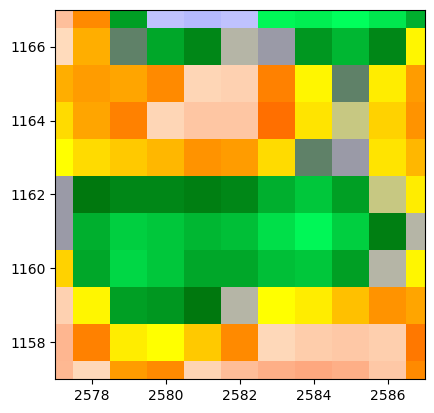

In [52]:
plt.figure()
plt.imshow(synop_img, vmin=-25, vmax=25, cmap='hmimag', origin='lower')
plt.ylim([1157,1167])
plt.xlim([2577,2587])

(2577.0, 2587.0)

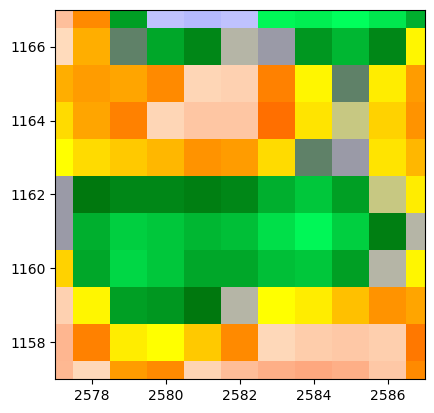

In [53]:
plt.figure()
plt.imshow(synop_img, vmin=-25, vmax=25, cmap='hmimag', origin='lower')
plt.ylim([1157,1167])
plt.xlim([2577,2587])

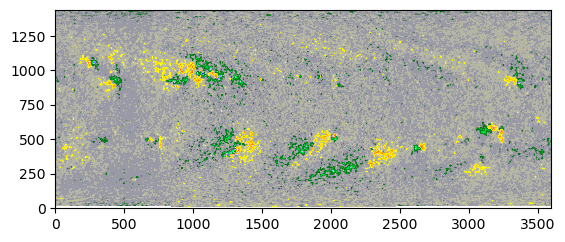

In [54]:
plt.figure()
plt.imshow(synop_img, vmin=-1500, vmax=1500, cmap='hmimag', origin='lower')


In [55]:
%matplotlib widget

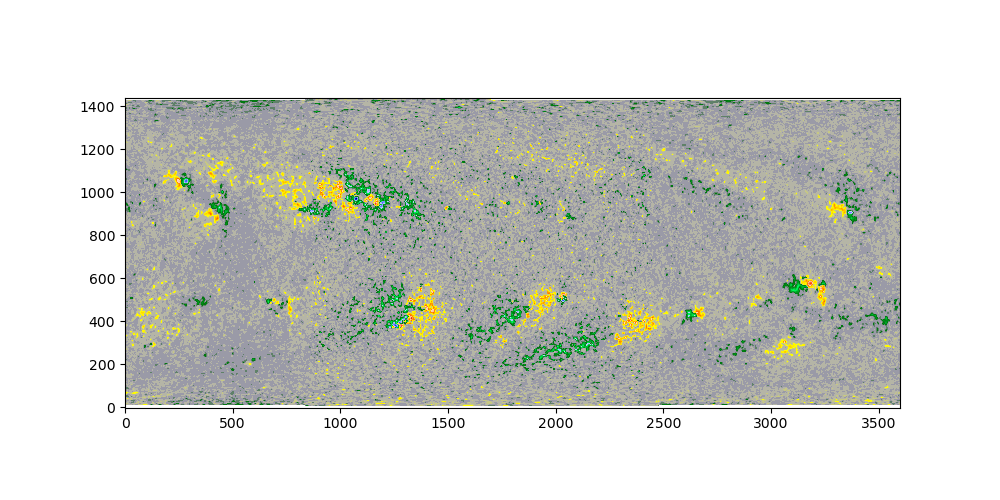

In [56]:
plt.figure(figsize=(10,5))
plt.imshow(synop_img, vmin=-1500, vmax=1500, cmap="hmimag", origin='lower')

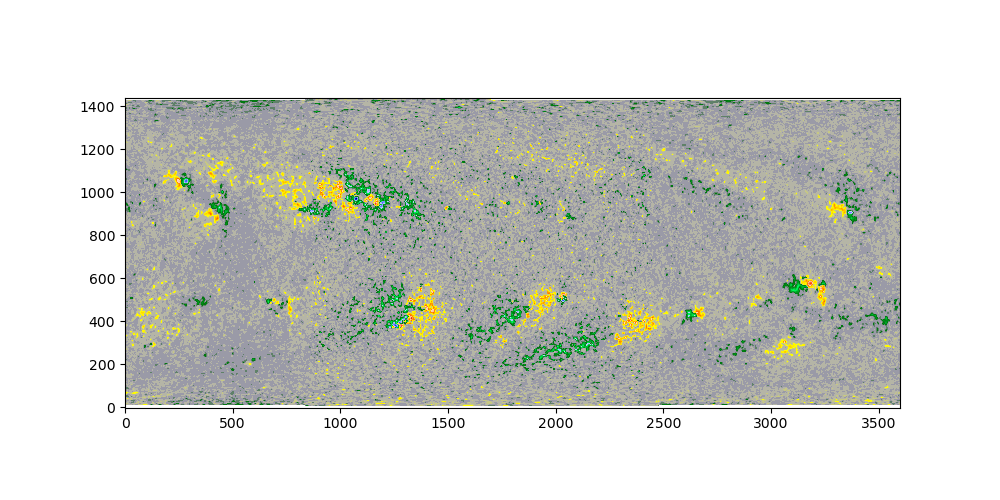

In [57]:
plt.figure(figsize=(10,5))
plt.imshow(synop_img, vmin=-1500, vmax=1500, cmap="hmimag", origin='lower')

In [58]:
#CR Start Point
2254-50/360.

2253.8611111111113

In [59]:
 "../cr%s/

SyntaxError: unterminated string literal (detected at line 1) (1082445955.py, line 1)

In [ ]:
#data1 = fits.open(path+'../cr2254/synopMl_awf0.05_nolim.fits')[0]
#data2 = fits.open(path+'../cr2254/synopMl_awf0.15_nolim.fits')[0]
#data3 = fits.open(path+'../cr2253.86/synopMl_CR2253.86_lowres.fits')[0]
#data4 = fits.open(path+'../cr2253.86/synopMl_CR2253.86_hires.fits')[0]
#
#data5 = fits.open(path+'../cr2253.9/synopMl_CR2253.9.fits')[0]
t1 = fits.open("/SUM35/D281475007301598/S00000/Ml.fits")[0]
t2 = fits.open(path+'../cr2255/synopMl_CR2255_limbcrop.fits')[0]

test = fits.open("/SUM44/D281475007277936/S00000/Ml.fits")[0]

In [ ]:
%matplotlib widget

In [ ]:
plt.figure()
plt.imshow(t1.data, vmin=-1500, vmax=1500, cmap="hmimag", origin='lower')

In [ ]:
plt.figure()
plt.imshow(t2.data, vmin=-1500, vmax=1500, cmap="hmimag", origin='lower')

In [ ]:
plt.figure()
plt.imshow(data4.data, vmin=-1500, vmax=1500, cmap="hmimag")

In [ ]:
plt.figure()
plt.imshow(data3.data, vmin=-1500, vmax=1500, cmap="hmimag")

In [ ]:
plt.figure()
plt.imshow(data1.data, vmin=-1500, vmax=1500, cmap="hmimag")

In [ ]:
plt.figure()
plt.imshow(data2.data, vmin=-1500, vmax=1500, cmap="hmimag")

In [ ]:
plt.figure()
plt.imshow(data3.data, vmin=-1500, vmax=1500, cmap="hmimag")

In [ ]:
inRecs = hmi_debug30deg12m
input_ds = "mps_loeschl.Ml_remap_CR2240_fast"

In [ ]:
drms_getkey, nRecs = get_drms_parameters(inRecs, input_ds)

In [ ]:
drms_getkey

## Bug Analysis

- verify length of weight functions wrt to their local cadence

###  Empty Image Slices on PHI Data

- EMPTY SLICES ARE NEXT TO SEGMENT TRANSITIONS
- 20° jump around CRLN_OBS 330! --> weight functions look fine though


- Width of empty stripes is reduced in chwidth 1.0 slope compared to the 0.5 slope
- chwidth 2.0 slope doesn't seem to solve the problem. Check weights again
- empty stripe only gets smaller from within its segment (right side). left side stays on the border
- should be a WF width issue! -> doesn't look like it
- HAPPENS AT THE SEGMENT TRANSITION -> FUCK

### Nans related to Weight Function Width

- 1.0 chwidth slope works
- 0.75 chwidth slope causes NaNs!
- 0.5 chwidth slope causes NaNs!

TODO RETHINK HOW WIDE THE SLICE AND WEIGHT MUST BE

### Missing Column at Segment Transition

- subSynop splits data into 60° segments
- each first column triggers the else branch of if(nptsfinal)
- this seems to happen because there's no overlap with previous data
- these columsn are the first data points and can't build an average with the previous cell

In [ ]:
ds = np.arange(0,6)
synRange = 60.0
cr = 2240
synstep = 0.1
synstart = (cr - 1) * 360.0 + 0.0 * synstep
synend = cr * 360.0 - 1.0 * synstep

In [ ]:
synend

In [ ]:
ds = 0

In [ ]:
subSynopStart = synstart + ds * synRange
subSynopEnd = synstart + (ds + 1) * synRange - synstep
SyncolStart = rint((synend - subSynopStart) / synstep)
SyncolEnd   = rint((synend - subSynopEnd) / synstep)

In [ ]:
SyncolStart, SyncolEnd

In [ ]:
SyncolStart, SyncolEnd

In [ ]:
synend

In [ ]:
subSynopStart

## Adaptive Weight Functions Tests

In [ ]:
# TODO
# try awf with cosinus wing to prevent sharp transitions
# cos(0:pi) mapped on your steps
# check if weight function is in sigma calculation

In [ ]:
%matplotlib widget

In [ ]:
phi_times_all = "2021.01.22_10:23:20_TAI,2021.01.22_12:03:52_TAI,2021.01.22_13:44:07_TAI,2021.01.22_15:24:06_TAI,2021.01.22_17:28:45_TAI,2021.01.22_20:23:02_TAI,2021.01.22_22:02:42_TAI,2021.01.22_23:42:32_TAI,2021.01.23_00:57:34_TAI,2021.01.23_03:02:56_TAI,2021.01.23_04:43:27_TAI,2021.01.23_09:45:22_TAI,2021.01.23_14:20:46_TAI,2021.01.24_10:44:38_TAI,2021.01.26_02:35:58_TAI,2021.01.26_22:31:58_TAI,2021.01.27_18:29:10_TAI,2021.01.28_14:26:45_TAI,2021.01.29_10:24:09_TAI,2021.01.30_06:22:08_TAI,2021.01.31_02:22:32_TAI,2021.01.31_22:26:52_TAI,2021.02.01_18:35:19_TAI,2021.02.02_14:47:06_TAI,2021.02.03_11:01:42_TAI,2021.02.15_18:21:23_TAI,2021.02.16_14:36:09_TAI,2021.02.17_10:45:54_TAI,2021.02.17_20:48:10_TAI,2021.02.18_01:48:48_TAI,2021.02.18_06:51:12_TAI"

In [ ]:
phi_times  = "2021.01.22_17:28:45_TAI,2021.01.23_14:20:46_TAI,2021.01.24_10:44:38_TAI,2021.01.26_02:35:58_TAI,2021.01.26_22:31:58_TAI,2021.01.27_18:29:10_TAI,2021.01.28_14:26:45_TAI,2021.01.29_10:24:09_TAI,2021.01.30_06:22:08_TAI,2021.01.31_02:22:32_TAI,2021.01.31_22:26:52_TAI,2021.02.01_18:35:19_TAI,2021.02.02_14:47:06_TAI,2021.02.03_11:01:42_TAI"
phi_times2 = "2021.01.22_17:28:45_TAI,2021.01.23_14:20:46_TAI,2021.01.24_10:44:38_TAI,2021.01.26_02:35:58_TAI,2021.01.26_22:31:58_TAI,2021.01.27_18:29:10_TAI,2021.01.28_14:26:45_TAI,2021.01.29_10:24:09_TAI,2021.01.30_06:22:08_TAI,2021.01.31_02:22:32_TAI,2021.01.31_22:26:52_TAI,2021.02.01_18:35:19_TAI,2021.02.02_14:47:06_TAI,2021.02.03_11:01:42_TAI,2021.02.15_18:21:23_TAI,2021.02.16_14:36:09_TAI,2021.02.17_10:45:54_TAI,2021.02.17_20:48:10_TAI,2021.02.18_01:48:48_TAI,2021.02.18_06:51:12_TAI"

In [ ]:
range2 = np.arange(0,  -0.5, -0.5/5)[::-1]
range2

In [ ]:
1-np.cos(range2*np.pi)**2

In [ ]:
hmi_debug30deg12m

In [ ]:
mrd_cont = adjacent_merdian_contributions(720, 20, 70, 75, 75)

In [ ]:
#drms_getkey, nRecs = get_drms_parameters(timestring2240_phi_hmi2h, "mps_loeschl.Ml_remap_CR2240_fast")
drms_getkey, nRecs = get_drms_parameters(inRecs["4h"], "mps_loeschl.B3comp_disambR_remap_final_720s")
weights, cadences = adaptive_weight_functions(drms_getkey, 0.1, mrd_cont=mrd_cont, lim=False)

In [ ]:
weights[0][::-1] #2h

In [ ]:
weights[0][::-1] #12m

In [ ]:
len(weights[32][::-1])/2

In [ ]:
for i, rec in enumerate(drms_getkey):
    print(i,  rec['CRLN_OBS'], rec['T_REC'], cadences[i], len(weights[i]))

In [ ]:
cadences

In [ ]:
%matplotlib widget

In [ ]:
synstep = 0.1
pph = (2.2/4)/synstep # pix per hour approximated from HMI cadence    

#drms_getkey, nRecs = get_drms_parameters(timestring2240_phi_hmi2h, "mps_loeschl.Ml_remap_CR2240_fast")
#weights, cadences = adaptive_weight_functions(drms_getkey, synstep)

mrd_cont = adjacent_merdian_contributions(720, 20, 70, 5, 5)
drms_getkey, nRecs = get_drms_parameters(inRecs["4h"], "mps_loeschl.B3comp_disambR_remap_final_720s")
weights, cadences = adaptive_weight_functions(drms_getkey, 0.1, mrd_cont, nimg=3, lim=True)
#weights, cadences = adaptive_weight_functions(drms_getkey, 0.1, mrd_cont=0.75, lim=False)

# 0:5 for HMI
# 17:23 for HMI/PHI transition incl the 39h cadence
#
start = 10
end   = 14
indices = np.arange(start, end)
    
multi = 3 # width as multiple of chwidth

xx = []
mids = []
widths = []
chwidths = []

for i, index in enumerate(indices):
    
    widths.append(len(weights[index][0]))
    chwidths.append(np.floor(cadences[index]*pph/2).astype(int))
    
    if i > 0:
        xstart = xx[-1][-1] - (multi+1)*chwidths[i-1][1]# previous end
        xend   = xstart + multi*np.sum(chwidths[i])+1
        xx.append(np.arange(xstart, xend))
        mids.append(xstart+multi*chwidths[i][0])
        
    else:
        #xx.append(np.arange(0, len(weights[indices[0]]))
        xstart = 0
        xend = multi*np.sum(chwidths[0])+1
        xx.append(np.arange(xstart, xend))
        mids.append(xx[-1][0]+multi*chwidths[0][0])

plt.figure()        
for i, x in enumerate(xx): #(x, i) in zip(xx, indices):    
    middle = len(weights[indices[i]][0])//2
    plt.plot(x, weights[indices[i]][0][::-1][middle-multi*chwidths[i][0]:middle+multi*chwidths[i][1]+1])
    
    plt.vlines(x[0]+multi*chwidths[i][0], 0, 1, colors='black', linestyle='dotted')
    plt.vlines(x[0]+multi*chwidths[i][0]-chwidths[i][0], -0.05, 1.05, colors='black')
    plt.vlines(x[0]+multi*chwidths[i][0]+chwidths[i][1], -0.05, 1.05, colors='black')

    plt.xlim(0, 350)
    plt.ylim(-0.05, 1.05)

plt.xlabel("Pixels")
plt.ylabel("Weight Factor")
plt.title('Adaptive Weight Functions')
plt.tight_layout()

#plt.savefig('./plots/adaptive_weight_functions.png', dpi=100)

plt.show()

In [ ]:
5.03194444*5.5*3/2

In [ ]:
24*5.5/2

In [ ]:
cadences

In [ ]:
"2021.01.21_06:36:00_TAI-2021.01.22_16:36:00_TAI@2h, \
2021.01.22_17:28:45_TAI, \
2021.01.23_14:20:46_TAI, \
2021.01.24_10:44:38_TAI, \
2021.01.26_02:35:58_TAI, \
2021.01.26_22:31:58_TAI, \
2021.01.27_18:29:10_TAI, \
2021.01.28_14:26:45_TAI, \
2021.01.29_10:24:09_TAI, \
2021.01.30_06:22:08_TAI, \
2021.01.31_02:22:32_TAI, \
2021.01.31_22:26:52_TAI, \
2021.02.01_18:35:19_TAI, \
2021.02.02_14:47:06_TAI, \
2021.02.03_11:01:42_TAI, \
2021.02.03_12:36:00_TAI-2021.02.19_14:36:00_TAI@2h"

'2021.01.21_06:36:00_TAI-2021.01.22_16:36:00_TAI@2h, 2021.01.22_17:28:45_TAI, 2021.01.23_14:20:46_TAI, 2021.01.24_10:44:38_TAI, 2021.01.26_02:35:58_TAI, 2021.01.26_22:31:58_TAI, 2021.01.27_18:29:10_TAI, 2021.01.28_14:26:45_TAI, 2021.01.29_10:24:09_TAI, 2021.01.30_06:22:08_TAI, 2021.01.31_02:22:32_TAI, 2021.01.31_22:26:52_TAI, 2021.02.01_18:35:19_TAI, 2021.02.02_14:47:06_TAI, 2021.02.03_11:01:42_TAI, 2021.02.03_12:36:00_TAI-2021.02.19_14:36:00_TAI@2h'

In [ ]:
slope = np.arange(0, 1, 0.2)

y0 = np.zeros(16)
y0[0:5] = slope
y0[5:11] = 1
y0[11:] = slope[::-1]

y1 = np.zeros(16)
y1[0:5] = slope**1.5
y1[5:11] = 1
y1[11:] = slope[::-1]**1.5

y2 = np.zeros(16)
y2[0:5] = slope**2
y2[5:11] = 1
y2[11:] = slope[::-1]**2

y3 = np.zeros(16)
y3[0:5] = slope**2.5
y3[5:11] = 1
y3[11:] = slope[::-1]**2.5

y4 = np.zeros(16)
y4[0:5] = slope**3
y4[5:11] = 1
y4[11:] = slope[::-1]**3

y5 = np.zeros(16)
y5[0:5] = slope**3.5
y5[5:11] = 1
y5[11:] = slope[::-1]**3.5

y6 = np.zeros(16)
y6[0:5] = slope**5
y6[5:11] = 1
y6[11:] = slope[::-1]**5

y7 = np.zeros(16)
y7[0:5] = slope**6
y7[5:11] = 1
y7[11:] = slope[::-1]**6



In [ ]:
plt.figure()
plt.plot(y0, label='linear')
plt.plot(y1, label='1/2')
plt.plot(y2, label='quadratic')
plt.plot(y3, label='3/2')
plt.plot(y4, label='cubic')
plt.plot(y5, label='5/2')
plt.plot(y6, label='quintratic?')
plt.plot(y7, label='sextratic?')

plt.vlines(7.5, -0.05, 1.05, colors='black', linestyle='dotted')
plt.vlines(5, -0.05, 1.05, colors='black')
plt.vlines(10,-0.05, 1.05, colors='black')

plt.vlines(2.5, -0.05, 1.05, colors='black', linestyle='dotted')
plt.vlines(12.5,-0.05, 1.05, colors='black', linestyle='dotted')
plt.vlines(0, -0.05, 1.05, colors='black')
plt.vlines(15,-0.05, 1.05, colors='black')

plt.grid()
plt.legend()
plt.show()

In [ ]:
n = 15
width = 3*n+1

range1 = np.arange(-1, -0.5,  0.5/n)
range2 = np.arange( 0, -0.5, -0.5/n)[::-1]

slope1 = 1-np.cos(range1*np.pi)**2
slope2 = 1-np.cos(range2*np.pi)**2
        
y0 = np.zeros(width)
y0[0:n]     = slope1**1
y0[n:2*n+1] = 1
y0[2*n+1:]  = slope2**1

y1 = np.zeros(width)
y1[0:n]     = slope1**1.5
y1[n:2*n+1] = 1
y1[2*n+1:]  = slope2**1.5

y2 = np.zeros(width)
y2[0:n]     = slope1**2
y2[n:2*n+1] = 1
y2[2*n+1:]  = slope2**2

y3 = np.zeros(width)
y3[0:n]     = slope1**2.5
y3[n:2*n+1] = 1
y3[2*n+1:]  = slope2**2.5

y4 = np.zeros(width)
y4[0:n]     = slope1**3
y4[n:2*n+1] = 1
y4[2*n+1:]  = slope2**3

y5 = np.zeros(width)
y5[0:n]     = slope1**3.5
y5[n:2*n+1] = 1
y5[2*n+1:]  = slope2**3.5

y6 = np.zeros(width)
y6[0:n]     = slope1**5
y6[n:2*n+1] = 1
y6[2*n+1:]  = slope2**5

y7 = np.zeros(width)
y7[0:n]     = slope1**6
y7[n:2*n+1] = 1
y7[2*n+1:]  = slope2**6

In [ ]:
plt.figure()
plt.plot(y0, label='linear')
plt.plot(y1, label='1/2')
plt.plot(y2, label='quadratic')
plt.plot(y3, label='3/2')
plt.plot(y4, label='cubic')
plt.plot(y5, label='5/2')
plt.plot(y6, label='quintratic?')
plt.plot(y7, label='sextratic?')

plt.vlines(7.5, -0.05, 1.05, colors='black', linestyle='dotted')
plt.vlines(5, -0.05, 1.05, colors='black')
plt.vlines(10,-0.05, 1.05, colors='black')

plt.vlines(2.5, -0.05, 1.05, colors='black', linestyle='dotted')
plt.vlines(12.5,-0.05, 1.05, colors='black', linestyle='dotted')
plt.vlines(0, -0.05, 1.05, colors='black')
plt.vlines(15,-0.05, 1.05, colors='black')

plt.grid()
plt.legend()
plt.show()

## Code Graveyard